# 서울시 공공자전거(따릉이) 이용 행태 및 수요 예측 모델링
## 기상 요인과 상권 특성의 Interaction 및 Non-linear Analysis를 중심으로

컴퓨터공학과 22100757 이규한

## 1. 프로젝트 개요 (Project Overview)

본 프로젝트는 서울시 따릉이 이용 내역, 기상(기온·강수·미세먼지), 캘린더(공휴일·시험기간) 정보를 결합한 '일별 상권별 종합 데이터셋'을 구축하여 따릉이 수요를 예측하고 이용 행태를 분석함.

**사용 데이터셋 (기간: 2026.03.01 ~ 2026.05.15)**
* 서울시 공공자전거 대여소별 대여/반납 승객수 정보 및 마스터 정보
* 기상청 종관기상관측 (ASOS) 데이터 및 황사관측 (PM10) 데이터

대여소는 입지적 특징에 따라 세 가지 상권으로 분류함:
* **Office (오피스 상권)**: 직장인 통근 수요 밀집 지역
* **Leisure (한강 여가 상권)**: 주말 나들이 수요 집중 지역
* **University (대학 상권)**: 학생들의 통학 및 생활 이동 수요 지역

**데이터 분석 주요 목적**
기상 요인(`temp`, `precip`, `pm10`)과 사회적/공간적 요인(`station_type`, `is_weekend` 등)이 수요에 미치는 영향을 파악함.
1. **상권 유형에 따른 이용 동기 분화 및 교호작용 규명**: 평일/주말 및 상권에 따른 대여량 차이를 분석.
2. **기상 요인 비선형적 임계선(Threshold) 탐색**: 기온 상승에 따른 수요 한계점 및 미세먼지 차단 효과 분석.
3. **도시 여가 패턴(Circular Trips) 특성 규명**: 저녁 시간대 한강공원 주변의 레저형 순환 경로 특성 분석.
4. **시계열 잔차 자기상관 통제**: 회귀 분석의 통계적 신뢰성 확보.


In [1]:
# 분석에 필요한 라이브러리를 로드함.
import os
import glob
import pandas as pd
import numpy as np
import traceback

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data')

WEATHER_DIR = os.path.join(DATA_DIR, '기상정보(03.31_05.21)')
BIKE_DIR = os.path.join(DATA_DIR, '따릉이(03,04,05.01_05.15)')
MASTER_DIR = os.path.join(DATA_DIR, '따릉이_마스터정보(대여소_id)')
DUST_DIR = os.path.join(DATA_DIR, '미세먼지 정보(03.31_05.21)')

START_DATE = '2026-03-01'
END_DATE = '2026-05-15'

# 사용자 정의 함수를 선언함.
def find_encoding(file_path):
    for enc in ['utf-8', 'cp949', 'euc-kr']:
        try:
            pd.read_csv(file_path, encoding=enc, nrows=1)
            return enc
        except UnicodeDecodeError:
            continue
    return 'cp949'

In [2]:
try:
    def load_master_data():
        master_files = glob.glob(os.path.join(MASTER_DIR, '*.csv'))
        if not master_files:
            raise FileNotFoundError("마스터 데이터 폴더에 CSV 파일이 없습니다.")
        master_file = master_files[0]
        enc = find_encoding(master_file)
        master_df = pd.read_csv(master_file, encoding=enc)
        
        station_name_col = next((col for col in master_df.columns if '명' in col or '이름' in col), master_df.columns[2])
        station_id_col = next((col for col in master_df.columns if 'ID' in col.upper() or '번호' in col), master_df.columns[0])
        
        office_keywords = ['여의도역', '강남역', '광화문역', '을지로입구역', '시청역', '선릉역', '삼성역', '종각역', '가산디지털단지역', '판교역', '공덕역']
        leisure_keywords = ['여의나루역', '뚝섬유원지역', '서울숲역', '반포한강공원', '망원한강공원', '올림픽공원', '월드컵경기장', '어린이대공원', '노들섬', '석촌호수']
        university_keywords = ['공릉', '서울과학기술대학교']

        def assign_station_type(name):
            name = str(name)
            for kw in office_keywords:
                if kw in name: return 'Office'
            for kw in leisure_keywords:
                if kw in name: return 'Leisure'
            for kw in university_keywords:
                if kw in name: return 'University'
            return None

        master_df['station_type'] = master_df[station_name_col].apply(assign_station_type)
        target_master_df = master_df.dropna(subset=['station_type']).copy()
        target_master_df = target_master_df[[station_id_col, station_name_col, 'station_type']]
        target_master_df.columns = ['station_id', 'station_name', 'station_type']
        target_master_df = target_master_df.drop_duplicates(subset=['station_id'])
        return target_master_df

    target_master_df = load_master_data()
except Exception as e:
    traceback.print_exc()


In [3]:
try:
    def load_and_filter_raw_bike_data(folder_path, target_master_df):
        all_files = glob.glob(os.path.join(folder_path, '**', '*.csv'), recursive=True)
        df_list = []
        target_station_ids = target_master_df['station_id'].unique()

        for file in all_files:
            enc = find_encoding(file)
            df = pd.read_csv(file, encoding=enc)
            start_id_cols = [c for c in df.columns if '시작' in c and 'ID' in c.upper()]
            if not start_id_cols:
                start_id_cols = [c for c in df.columns if '대여소_ID' in c.upper() or '대여대여소' in c]
            if not start_id_cols: continue
            
            join_col = start_id_cols[0]
            filtered_df = df[df[join_col].isin(target_station_ids)].copy()
            if filtered_df.empty: continue
                
            filtered_df = pd.merge(filtered_df, target_master_df[['station_id', 'station_type']], left_on=join_col, right_on='station_id', how='inner')
            filtered_df.drop(columns=['station_id'], inplace=True)
            
            date_col = next((c for c in filtered_df.columns if '날짜' in c or '일자' in c), filtered_df.columns[0])
            filtered_df['date'] = pd.to_datetime(filtered_df[date_col].astype(str).str.replace('-', ''), errors='coerce').dt.normalize()
            filtered_df = filtered_df.dropna(subset=['date'])
            df_list.append(filtered_df)
                
        if not df_list: return pd.DataFrame()
        return pd.concat(df_list, ignore_index=True)

    bike_raw_df = load_and_filter_raw_bike_data(BIKE_DIR, target_master_df)
except Exception as e:
    traceback.print_exc()

In [4]:
try:
    def load_environment_data(folder_path, value_col_hints, output_col_name):
        all_files = glob.glob(os.path.join(folder_path, '**', '*.csv'), recursive=True)
        df_list = []
        for file in all_files:
            enc = find_encoding(file)
            df = pd.read_csv(file, encoding=enc)
            station_col = next((c for c in df.columns if '지점' in c), df.columns[0])
            station_ids = pd.to_numeric(df[station_col], errors='coerce')
            # 기상청 종관기상관측은 서울(108번 지점) 데이터만 추출하여 사용함
            df = df[station_ids == 108].copy()
            if df.empty: continue
            
            date_col = next((c for c in df.columns if '일시' in c or '일자' in c or '날짜' in c), df.columns[2])
            val_cols = []
            for hint in value_col_hints:
                found = next((c for c in df.columns if hint in c), None)
                if found: val_cols.append(found)
                
            if val_cols:
                sub_df = df[[date_col] + val_cols].copy()
                sub_df['date'] = pd.to_datetime(sub_df[date_col], errors='coerce').dt.normalize()
                sub_df = sub_df.dropna(subset=['date'])
                sub_df = sub_df.drop(columns=[date_col])
                df_list.append(sub_df)
                
        if not df_list: return pd.DataFrame()
        merged_env = pd.concat(df_list, ignore_index=True)
        merged_env = merged_env.groupby('date').mean().reset_index()
        
        rename_dict = {f: o for f, o in zip([next((c for c in merged_env.columns if h in c), None) for h in value_col_hints], output_col_name) if f}
        return merged_env.rename(columns=rename_dict)
    # 기상 데이터 중 기온 및 강수량만 선택적으로 사용함
    weather_df = load_environment_data(WEATHER_DIR, ['기온', '강수'], ['temp', 'precip'])
    # 미세먼지 데이터는 일평균 PM10 농도만 사용함
    dust_df = load_environment_data(DUST_DIR, ['미세먼지', 'PM10'], ['pm10', 'pm10'])

    # 데이터셋을 병합하여 전처리를 수행함.
    env_df = pd.merge(weather_df, dust_df, on='date', how='outer') if not weather_df.empty and not dust_df.empty else weather_df if not weather_df.empty else dust_df
    if not env_df.empty:
        env_df.set_index('date', inplace=True)
        env_df.sort_index(inplace=True)
        env_df = env_df.reindex(pd.date_range(start=START_DATE, end=END_DATE))
        if 'precip' in env_df.columns: env_df['precip'] = env_df['precip'].fillna(0)
        if 'temp' in env_df.columns: env_df['temp'] = env_df['temp'].interpolate(method='time').bfill().ffill()
        if 'pm10' in env_df.columns: env_df['pm10'] = env_df['pm10'].interpolate(method='time').bfill().ffill()
        env_df.reset_index(names='date', inplace=True)
except Exception as e:
    traceback.print_exc()

In [5]:
try:
    if not bike_raw_df.empty and not env_df.empty:
        final_df = pd.merge(bike_raw_df, env_df, on='date', how='left')
        mask = (final_df['date'] >= pd.to_datetime(START_DATE)) & (final_df['date'] <= pd.to_datetime(END_DATE))
        final_df = final_df.loc[mask].copy()
        final_df['is_weekend'] = final_df['date'].dt.dayofweek.isin([5, 6]).astype(int)
        final_df['station_type'] = final_df['station_type'].astype('category')
        final_df['is_weekend'] = final_df['is_weekend'].astype('category')
        cols = final_df.columns.tolist()
        cols.insert(0, cols.pop(cols.index('date')))
        final_df = final_df[cols]
        output_path = os.path.join(BASE_DIR, 'preprocessed_data_for_public_bike.csv')
        final_df.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"전처리 완료: {output_path}")
except Exception as e:
    traceback.print_exc()

전처리 완료: /Users/gyuhan/Desktop/project/데이터분석 텀프/preprocessed_data_for_public_bike.csv


## Preprocessing Summary
수집된 대여 이력 및 기상, 미세먼지 데이터를 일별/상권별로 병합하고 정제하는 데이터 전처리를 수행함.


In [6]:
# 최종 전처리된 데이터셋(final_df)의 구조 및 기본 통계 정보를 확인함
try:
    print('=' * 60)
    print('전처리된 데이터 (final_df) 기본 정보')
    print('=' * 60)
    print(f'\n전체 행 수: {len(final_df):,}행')
    print(f'컬럼 수: {len(final_df.columns)}개')
    print(f'기간: {final_df["date"].min()} ~ {final_df["date"].max()}')
    print(f'\n상권별 대여 건수:')
    print(final_df.groupby('station_type', observed=False).size().to_string())
    print(f'\n--- 상위 5행 ---')
    display(final_df.head())
    print(f'\n--- 데이터 타입 ---')
    display(final_df.dtypes)
    print(f'\n--- 수치형 변수 기초 통계 ---')
    display(final_df.describe())
except Exception as e:
    traceback.print_exc()

전처리된 데이터 (final_df) 기본 정보

전체 행 수: 232,648행
컬럼 수: 16개
기간: 2026-03-01 00:00:00 ~ 2026-05-15 00:00:00

상권별 대여 건수:
station_type
Leisure       149367
Office         38243
University     45038

--- 상위 5행 ---


,date,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,station_type,temp,precip,pm10,is_weekend
0,2026-03-19,20260319,출발시간,1705,ST-1585,잠실3동_053_2,ST-488,암사1동_044_1,1,38.0,6206.0,Leisure,6.1,0.0,35.0,0
1,2026-03-19,20260319,출발시간,1600,ST-1668,명동_001_10,ST-336,"종로1,2,3,4가동_003_9",1,2.0,364.0,Office,6.1,0.0,35.0,0
2,2026-03-19,20260319,출발시간,1245,ST-108,성수1가1동_029_1,ST-2341,성수1가1동_029_2,1,45.0,1516.0,Leisure,6.1,0.0,35.0,0
3,2026-03-19,20260319,출발시간,145,ST-602,공릉1동_045_1,ST-913,월계1동_017_1,1,8.0,1865.0,University,6.1,0.0,35.0,0
4,2026-03-19,20260319,출발시간,2040,ST-362,성수1가1동_003_1,ST-2321,화양동_040_1,1,12.0,3027.0,Leisure,6.1,0.0,35.0,0



--- 데이터 타입 ---


date            datetime64[ns]
기준_날짜                    int64
집계_기준                   object
기준_시간대                   int64
시작_대여소_ID               object
시작_대여소명                 object
종료_대여소_ID               object
종료_대여소명                 object
전체_건수                    int64
전체_이용_분                float64
전체_이용_거리               float64
station_type          category
temp                   float64
precip                 float64
pm10                   float64
is_weekend            category
dtype: object


--- 수치형 변수 기초 통계 ---


,date,기준_날짜,기준_시간대,전체_건수,전체_이용_분,전체_이용_거리,temp,precip,pm10
count,232648,2.326480e+05,232648.000000,232648.000000,225968.000000,225968.000000,232648.000000,232648.000000,232648.000000
mean,2026-04-11 23:39:05.118806272,2.026041e+07,1504.768771,1.112144,28.529863,3069.031385,13.945884,1.128809,42.530239
min,2026-03-01 00:00:00,2.026030e+07,0.000000,1.000000,1.000000,300.000000,1.000000,0.000000,15.000000
25%,2026-03-26 00:00:00,2.026033e+07,1130.000000,1.000000,6.000000,892.000000,11.000000,0.000000,30.000000
50%,2026-04-14 00:00:00,2.026041e+07,1620.000000,1.000000,14.000000,1649.000000,14.300000,0.000000,40.000000
75%,2026-04-30 00:00:00,2.026043e+07,1900.000000,1.000000,35.000000,3446.000000,17.400000,0.920000,51.000000
max,2026-05-15 00:00:00,2.026052e+07,2355.000000,11.000000,1358.000000,132401.000000,24.200000,21.420000,138.000000
std,NaN,7.158277e+01,512.167742,0.380441,39.237109,4151.047818,4.978337,2.613147,19.141206


---
## 2. 분석 파이프라인 요약 (Methodology Summary)

분석은 데이터 전처리, 비선형 회귀, 분류 모델 학습 및 검증 순으로 진행됨.

* **데이터 전처리 및 EDA**: 시간 단위 이력을 집계하고, 상권 및 주말에 따른 대여량 분포 시각화 및 다중공선성 사전 탐색.
* **다중 선형 회귀 및 잔차 진단**: 교호작용 항(Interaction Terms)을 포함한 회귀 모델 적합 및 ANOVA 검정, 잔차 진단 플롯 구현.
* **분류 및 리샘플링 (Cross-Validation, Bootstrap)**: 수요 수준 분류(Logistic, LDA, QDA, KNN) 및 일반화 성능 평가.
* **모델 선택 및 정규화**: Stepwise Selection, Ridge/Lasso, PCR/PLS를 통한 변수 선택 및 차원 축소.
* **비선형 모델링**: Splines, LOWESS, GAM을 활용한 기상 요인의 비선형 관계 포착 및 PDP 도출.
* **시계열 진단 및 통제**: ACF/PACF 분석 및 Lag-1 시차 변수를 통한 시간적 의존성(Autocorrelation) 보정.
* **여가 상권 특화 분석**: 순환 대여(Circular Trips) 패턴 및 이용 시간과 기온 간의 상관관계 심층 분석.


In [7]:
# pandas 및 시각화 라이브러리(seaborn, matplotlib)를 활용한 탐색적 데이터 분석(EDA)

# 분석에 필요한 라이브러리를 로드함.
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from ISLP.models import summarize, poly, ModelSpec as MS, sklearn_sm, bs
from sklearn.model_selection import KFold, cross_validate
import copy


# ModelSpec 객체를 복사하여 개별 Fold마다 독립적으로 Fit되도록 함
orig_fit = sklearn_sm.fit

# 사용자 정의 함수를 선언함.
def robust_fit(self, X, y):
    if self.model_spec is not None:
        self.model_spec = copy.deepcopy(self.model_spec)
        self.model_spec_ = self.model_spec.fit(X)
        X = self.model_spec_.transform(X)
    self.model_ = self.model_type(y, X, **self.model_args)
    self.results_ = self.model_.fit()
    return self

sklearn_sm.fit = robust_fit


plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('preprocessed_data_for_public_bike.csv')


## 1. Exploratory Data Analysis (EDA): Hourly Rental Patterns by Station Type
원본 데이터의 `기준_시간대`를 파싱하여 Office, Leisure, University 상권의 시간대별 대여 집중도를 비교 분석함. 이를 통해 공간적 특성에 따른 이용 시간대 분산 패턴을 파악함.


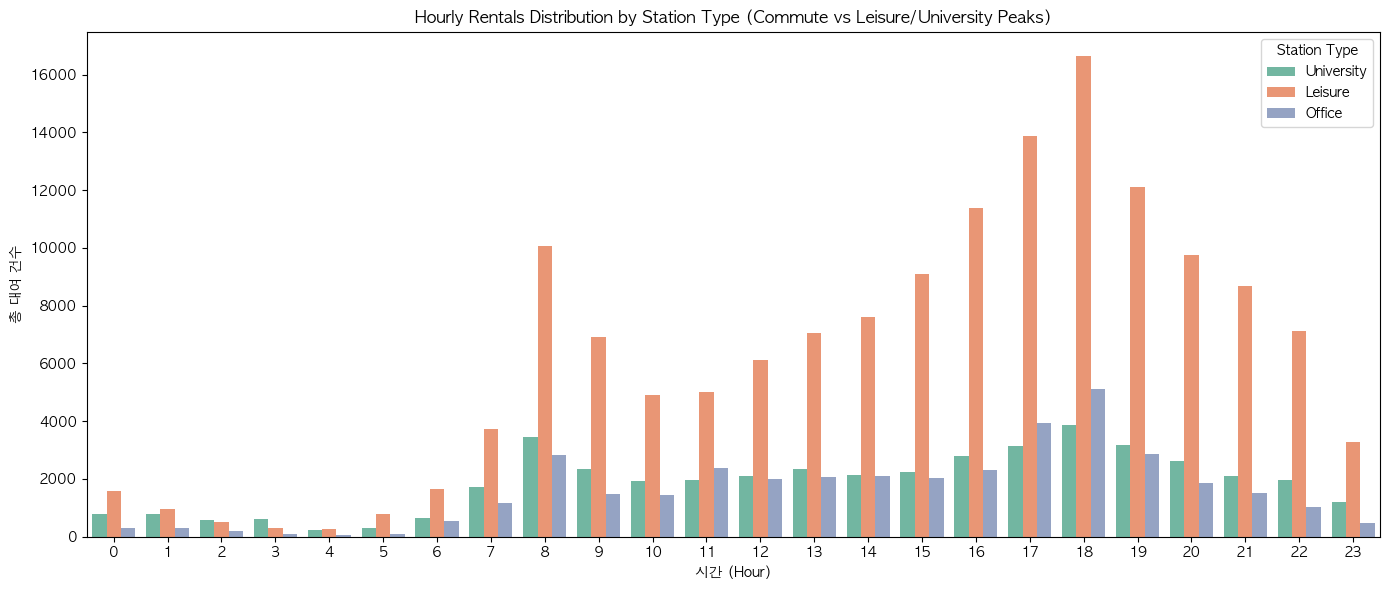

In [8]:
# 시간 단위 대여 정보 파싱 및 대여소 위치 정보를 바탕으로 상권 유형(station_type) 분류 파생변수를 생성함
# 기준 시간대 변수를 시간(Hour) 단위 수치 데이터로 파싱함
df['hour'] = df['기준_시간대'].astype(str).str.zfill(4).str[:2]
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df = df.dropna(subset=['hour'])
df['hour'] = df['hour'].astype(int)

# 분석 결과를 시각화함.
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='hour', hue='station_type', palette='Set2')
plt.title('Hourly Rentals Distribution by Station Type (Commute vs Leisure/University Peaks)')
plt.xlabel('시간 (Hour)')
plt.ylabel('총 대여 건수')
plt.legend(title='Station Type')
plt.tight_layout()
plt.show()


## 1-1. Correlation Analysis of Predictors
Exploratory Data Analysis (EDA)의 핵심 단계로서 변수 간 Pearson 상관계수 행렬을 계산하고 Heatmap으로 시각화함. 이를 통해 후속 다중선형회귀분석의 다중공선성 발생 가능성을 사전에 진단함.


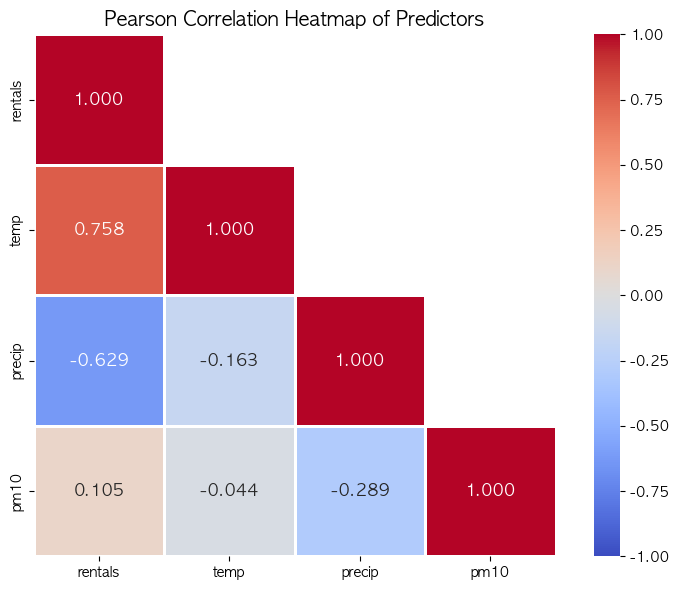

In [9]:
# Pearson 상관계수 행렬을 계산하고 Heatmap으로 시각화하여 변수 간 상관관계를 사전 점검함
# 상관관계 행렬 및 Heatmap 시각화 수행
numeric_cols = ['rentals', 'temp', 'precip', 'pm10']
# daily_df가 아직 생성되지 않았으므로 일별 집계를 미리 수행
corr_df = df.groupby('date')[numeric_cols[1:]].mean().reset_index()
corr_df['rentals'] = df.groupby('date').size().values

# 분석 결과를 시각화함.
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = corr_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=1, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Pearson Correlation Heatmap of Predictors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 분석 결과 요약: Correlation 및 Interaction 분석 결과

* **기상 요인과의 상관관계**: 기온(`temp`)은 대여량과 강한 양의 상관관계(0.758)를 보이며, 강수량(`precip`)은 강한 음의 상관관계(-0.629)를 가짐을 확인함. 미세먼지(`pm10`)는 약한 양의 상관관계(0.105)를 가짐. 기온과 미세먼지 간의 상관관계는 -0.044로 매우 낮아 다중공선성 우려가 적음.
* **교호작용(Interaction) 효과** : `station_type`과 `is_weekend` 간의 Interaction Terms를 포함한 모델을 적합한 결과,
  * **여가 상권(Leisure)** 은 주말에 대여량이 유의미하게 급증하는 강한 양(+)의 Interaction Effects가 확인됨.
  * **오피스 상권(Office)** 은 평일 대비 주말 대여량이 크게 감소하는 음(-)의 Interaction Effects가 나타남.
  * ANOVA nested 모델 비교(F-test) 결과 매우 유의한 수준으로 나타나, 상권별 주말 효과의 Interaction을 반영하는 것이 모델 설명력을 유의미하게 향상시킴을 입증함.


## 2. Distribution of Ride Duration and Distance by Station Type and Weekend
상권 유형 및 주말 여부에 따른 이용 시간 및 주행 거리 분포 차이를 Boxplot으로 시각화하여 분석함.


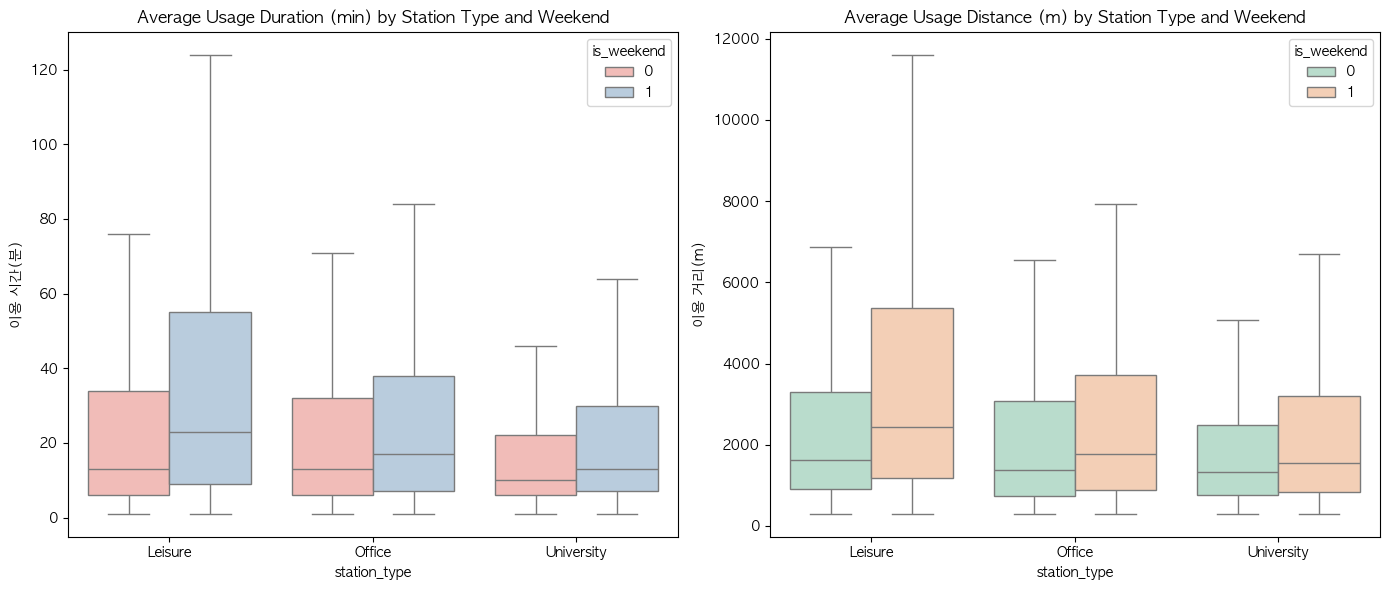

In [10]:
# 상권 유형 및 주말 여부별 이용 시간 및 이동 거리 분포 차이를 Boxplot으로 시각화

# 분석 결과를 시각화함.
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='station_type', y='전체_이용_분', hue='is_weekend', data=df, showfliers=False, palette='Pastel1')
plt.title('Average Usage Duration (min) by Station Type and Weekend')
plt.ylabel('이용 시간(분)')

plt.subplot(1, 2, 2)
sns.boxplot(x='station_type', y='전체_이용_거리', hue='is_weekend', data=df, showfliers=False, palette='Pastel2')
plt.title('Average Usage Distance (m) by Station Type and Weekend')
plt.ylabel('이용 거리(m)')

plt.tight_layout()
plt.show()


## 3. Feature Engineering of Special Dates (Exam Periods, Holidays) and Daily Aggregation
회귀 분석을 위해 대학 시험기간(is_exam) 및 공공 휴일(is_holiday) 특수 캘린더 변수를 더미화하고 데이터를 일별 단위로 집계 및 병합함.


In [11]:
# 대여 내역 데이터를 일별, 상권별 단위로 그룹화하여 일별 대여량(rentals)을 집계
df['date'] = pd.to_datetime(df['date'])

# 대학 시험기간(is_exam) 및 법정 공휴일(is_holiday) 특수 캘린더 변수를 더미로 추가
df['is_holiday'] = df['date'].isin(pd.to_datetime(['2026-05-01','2026-05-05'])).astype(int)
df['is_exam'] = ((df['date'] >= '2026-04-20') & (df['date'] <= '2026-04-27')).astype(int)

daily_df = df.groupby(['date', 'station_type', 'is_weekend', 'is_holiday', 'is_exam'], observed=True).agg({
    '전체_건수': 'sum', 'temp': 'mean', 'precip': 'mean', 'pm10': 'mean'
}).reset_index()
daily_df.rename(columns={'전체_건수': 'rentals'}, inplace=True)
daily_df = daily_df.dropna()

daily_df['station_type'] = daily_df['station_type'].astype('category')
daily_df['is_weekend'] = daily_df['is_weekend'].astype('category')
daily_df['is_holiday'] = daily_df['is_holiday'].astype('category')
daily_df['is_exam'] = daily_df['is_exam'].astype('category')

display(daily_df.head())

,date,station_type,is_weekend,is_holiday,is_exam,rentals,temp,precip,pm10
0,2026-03-01,Leisure,1,0,0,1786,9.1,0.53,22.0
1,2026-03-01,Office,1,0,0,200,9.1,0.53,22.0
2,2026-03-01,University,1,0,0,416,9.1,0.53,22.0
3,2026-03-02,Leisure,0,0,0,134,4.9,17.25,24.0
4,2026-03-02,Office,0,0,0,40,4.9,17.25,24.0


## 4. Multiple Linear Regression with Interaction Analysis and Diagnostics
기상 요인, 캘린더 변수 및 상권 유형 간의 다중선형회귀분석을 설계하고, 상권 유형과 주말 여부 간의 교호작용(Interaction Effects)을 모형에 포함하여 OLS 적합을 수행함.


,coef,std err,t,P>|t|
intercept,1628.6256,121.149,13.443,0.000
temp,47.0172,5.436,8.649,0.000
precip,-45.7442,7.058,-6.481,0.000
pm10,-0.4891,1.621,-0.302,0.763
station_type[Office],-1532.0000,77.805,-19.690,0.000
station_type[University],-1488.8000,77.805,-19.135,0.000
is_weekend[1],416.5716,105.048,3.966,0.000
is_holiday[1],654.0602,171.771,3.808,0.000
is_exam[1],46.4341,97.355,0.477,0.634
station_type[Office]:is_weekend,-701.4286,148.014,-4.739,0.000


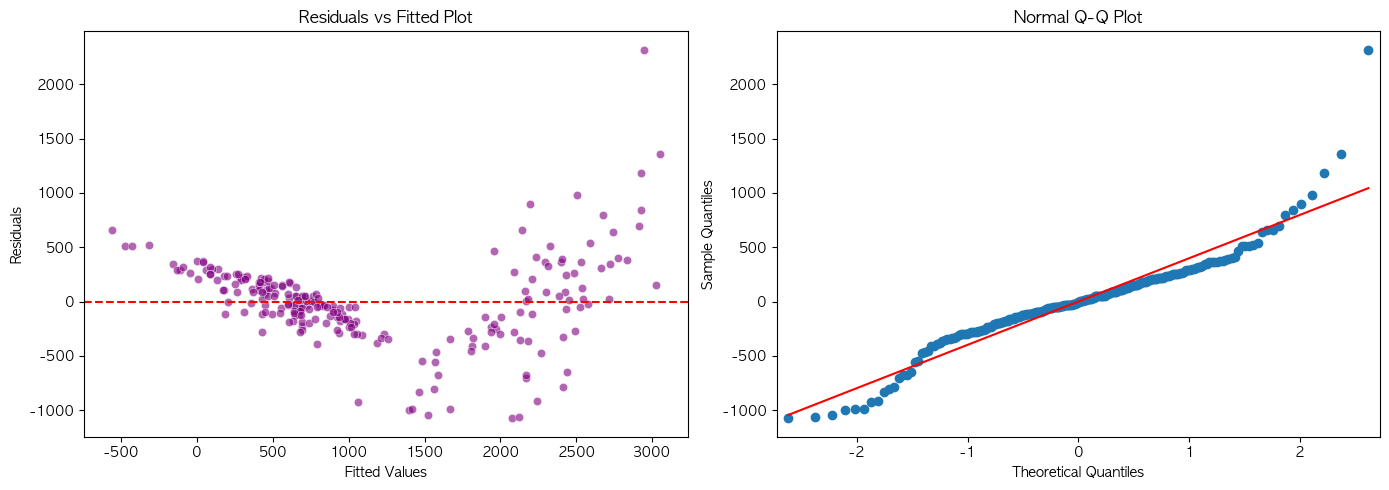

In [12]:
# station_type과 is_weekend 간의 Interaction Terms를 포함한 Multiple Linear Regression 모델을 적합
# Interaction Terms가 포함된 ModelSpec 생성 및 OLS 회귀 적합
design_inter = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', 
                   ('station_type', 'is_weekend')])
X_inter = design_inter.fit_transform(daily_df)
y = daily_df['rentals']

# 회귀 모델을 적합함.
model_mlr = sm.OLS(y, X_inter).fit()
display(summarize(model_mlr))

# OLS Residual Diagnostics 플롯 시각화

# 분석 결과를 시각화함.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=model_mlr.fittedvalues, y=model_mlr.resid, ax=ax[0], alpha=0.6, color='purple')
ax[0].axhline(0, color='r', linestyle='--')
ax[0].set_title('Residuals vs Fitted Plot')
ax[0].set_xlabel('Fitted Values')
ax[0].set_ylabel('Residuals')

sm.qqplot(model_mlr.resid, line='s', ax=ax[1])
ax[1].set_title('Normal Q-Q Plot')
plt.tight_layout()
plt.show()


## 4-1. Diagnostic Plots for Regression Residuals
회귀 모형의 가정을 검증하기 위해 잔차 진단 4대 플롯(Residuals vs Fitted, Normal Q-Q, Scale-Location, Residuals vs Leverage)을 구현하여 진단함.


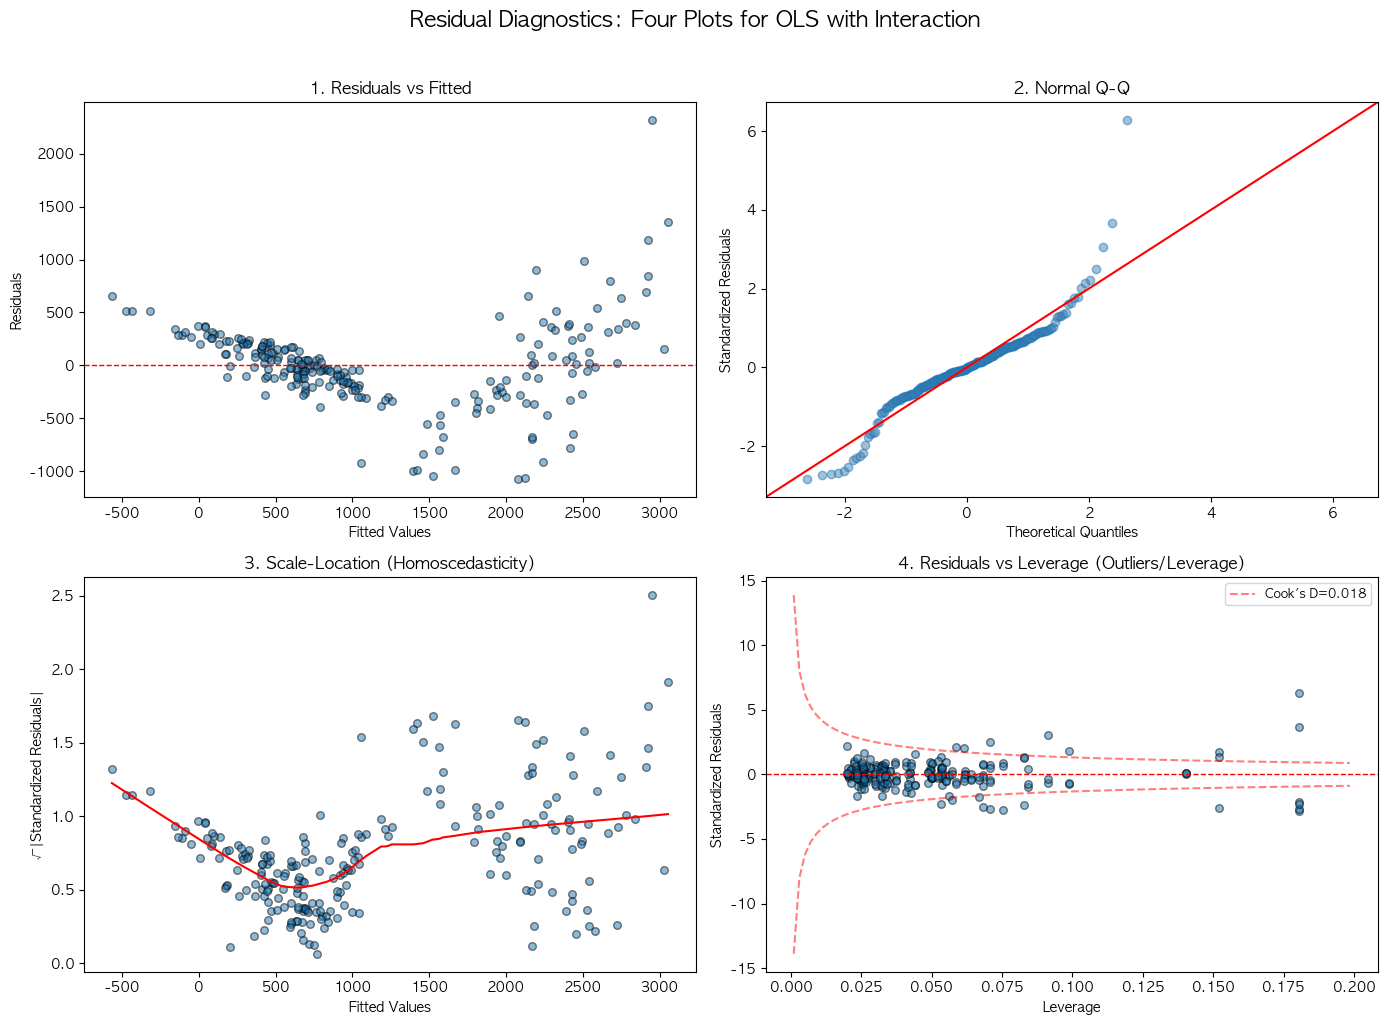

[Summary of Diagnostics]
  - Mean of Residuals: 0.0000 (Good if close to 0)
  - Shapiro-Wilk Normality Test p-value: 0.0000
  - Max Leverage: 0.1804, Mean Leverage: 0.0482
  - Number of High-leverage Points (h > 2p/n = 0.0965): 15


In [13]:
# OLS Residual Diagnostics 4대 플롯(Residuals vs Fitted, Normal Q-Q, Scale-Location, Residuals vs Leverage)을 구현하여 회귀 모델의 가정 충족 여부 점검
# 잔차 진단 4대 플롯(Residual Diagnostics) 구현

# 분석에 필요한 라이브러리를 로드함.
from statsmodels.stats.outliers_influence import OLSInfluence
from scipy import stats

# Interaction 모델의 OLS 적합 결과 활용
influence = OLSInfluence(model_mlr)
std_resid = influence.resid_studentized_internal
fitted_vals = model_mlr.fittedvalues
leverage = influence.hat_matrix_diag

# 분석 결과를 시각화함.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Residuals vs Fitted 플롯
ax1 = axes[0, 0]
ax1.scatter(fitted_vals, model_mlr.resid, alpha=0.5, edgecolors='k', s=30)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('1. Residuals vs Fitted', fontweight='bold')

# 2) Normal Q-Q 플롯
ax2 = axes[0, 1]
sm.qqplot(std_resid, line='45', ax=ax2, markerfacecolor='steelblue', alpha=0.5)
ax2.set_title('2. Normal Q-Q', fontweight='bold')
ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Standardized Residuals')

# 3) Scale-Location 플롯
ax3 = axes[1, 0]
sqrt_std_resid = np.sqrt(np.abs(std_resid))
ax3.scatter(fitted_vals, sqrt_std_resid, alpha=0.5, edgecolors='k', s=30)
# LOWESS 추세선 적합
lowess = sm.nonparametric.lowess(sqrt_std_resid, fitted_vals, frac=0.6)
ax3.plot(lowess[:, 0], lowess[:, 1], color='red', linewidth=1.5)
ax3.set_xlabel('Fitted Values')
ax3.set_ylabel('√|Standardized Residuals|')
ax3.set_title('3. Scale-Location (Homoscedasticity)', fontweight='bold')

# 4) Residuals vs Leverage 플롯
ax4 = axes[1, 1]
ax4.scatter(leverage, std_resid, alpha=0.5, edgecolors='k', s=30)
ax4.axhline(y=0, color='red', linestyle='--', linewidth=1)
# Cook's Distance 기준선 추가
p = model_mlr.df_model + 1  # 파라미터 수
n = len(fitted_vals)
cooks_threshold = 4 / n
x_range = np.linspace(0.001, max(leverage) * 1.1, 100)
for sign in [1, -1]:
    cooks_line = sign * np.sqrt(cooks_threshold * p * (1 - x_range) / x_range)
    ax4.plot(x_range, cooks_line, 'r--', alpha=0.5, label="Cook's D=" + f'{cooks_threshold:.3f}' if sign == 1 else '')
ax4.set_xlabel('Leverage')
ax4.set_ylabel('Standardized Residuals')
ax4.set_title('4. Residuals vs Leverage (Outliers/Leverage)', fontweight='bold')
ax4.legend(loc='upper right', fontsize=9)

plt.suptitle('Residual Diagnostics: Four Plots for OLS with Interaction', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('[Summary of Diagnostics]')
print(f'  - Mean of Residuals: {model_mlr.resid.mean():.4f} (Good if close to 0)')
print(f'  - Shapiro-Wilk Normality Test p-value: {stats.shapiro(model_mlr.resid[:min(5000, len(model_mlr.resid))])[1]:.4f}')
print(f'  - Max Leverage: {leverage.max():.4f}, Mean Leverage: {leverage.mean():.4f}')
high_leverage = np.sum(leverage > 2 * p / n)
print(f'  - Number of High-leverage Points (h > 2p/n = {2*p/n:.4f}): {high_leverage}')


## 5. ANOVA (Analysis of Variance) for Interaction Model Verification
기본 회귀 모델과 교호작용(Interaction) 및 특수일 변수가 추가된 확장 모델 간의 ANOVA nested F-test를 수행하여 모델 유의성을 검증함.


In [14]:
# 기본 선형회귀 모델과 Interaction 항이 추가된 확장 모델 간 ANOVA nested F-test를 수행
# Interaction 및 특수일 변수를 제외한 Base 모델 정의
design_base = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])
X_base = design_base.fit_transform(daily_df)

# 회귀 모델을 적합함.
model_base = sm.OLS(y, X_base).fit()

anova_res = sm.stats.anova_lm(model_base, model_mlr)
print("ANOVA Results: A p-value < 0.05 indicates that the expanded model with interaction terms is statistically significantly better.")
display(anova_res)


ANOVA Results: A p-value < 0.05 indicates that the expanded model with interaction terms is statistically significantly better.


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,221.0,4.251260e+07,0.0,NaN,NaN,NaN
1,217.0,3.612475e+07,4.0,6.387841e+06,9.592879,3.679509e-07


## 6. Feature Selection and Regularization: Lasso Regression Coefficient Analysis
Lasso(L1 Penalty) 정규화 회귀분석을 통해 다중공선성이 존재하는 다양한 피처들 중 대여량에 유의한 영향을 미치는 핵심 변수를 선택하고 계수 수축을 분석함.


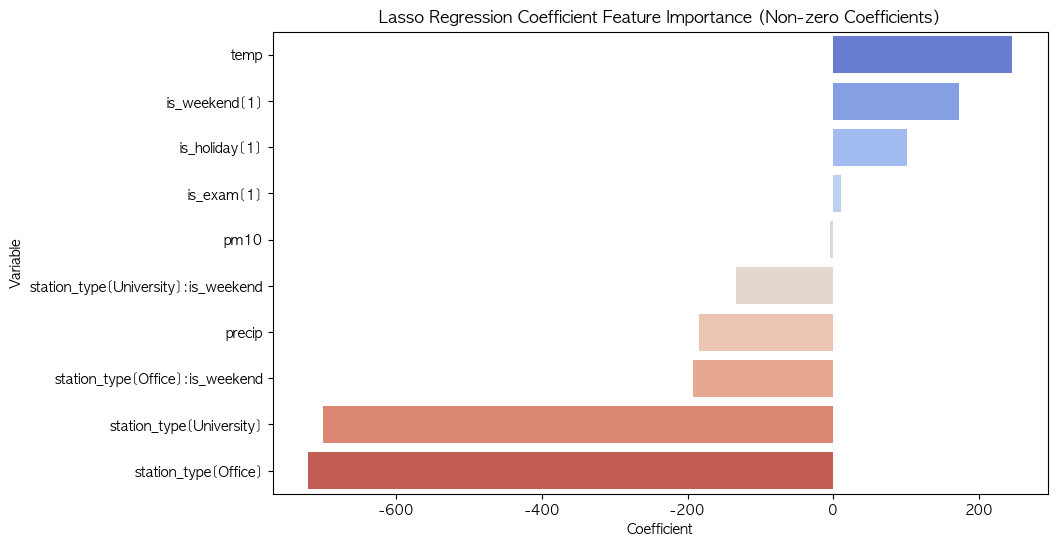

In [15]:
# Lasso(L1) 정규화 회귀분석 및 Cross-Validation을 통해 계수를 0으로 수축시키고 주요 변수를 선택하여 시각화

# 분석에 필요한 라이브러리를 로드함.
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# 변수 스케일링을 적용함.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_inter.drop(columns=['intercept']))
lasso = LassoCV(cv=5).fit(X_scaled, y)

coef_df = pd.DataFrame({'Variable': X_inter.columns[1:], 'Coefficient': lasso.coef_})
coef_df = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

# 분석 결과를 시각화함.
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Variable', hue='Variable', legend=False, data=coef_df, palette='coolwarm')
plt.title('Lasso Regression Coefficient Feature Importance (Non-zero Coefficients)')
plt.show()


## 7. Non-linear Regression: Polynomial Regression of Temperature
기온과 대여량 간의 비선형(Non-linear) 패턴을 포착하기 위해 2차 다항회귀(Polynomial Regression, Degree 2) 모델을 적합함.


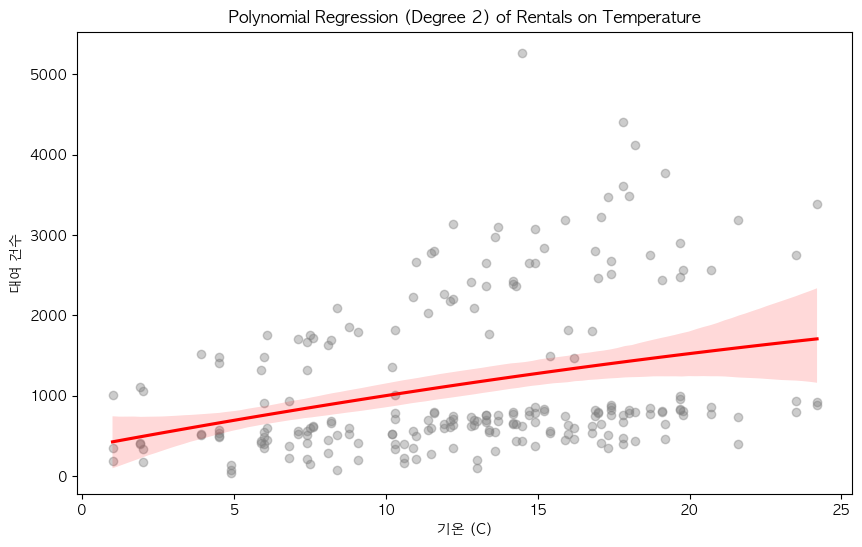

In [16]:
# 기온(temp)과 rentals 간의 Non-linear 관계를 2차 다항회귀(Polynomial Regression)로 모델링
design_poly = MS([poly('temp', degree=2), 'station_type', 'is_weekend'])
X_poly = design_poly.fit_transform(daily_df)

# 회귀 모델을 적합함.
model_poly = sm.OLS(y, X_poly).fit()

# 분석 결과를 시각화함.
plt.figure(figsize=(10, 6))
sns.regplot(x='temp', y='rentals', data=daily_df, order=2, scatter_kws={'alpha':0.4, 'color':'gray'}, line_kws={'color':'red'})
plt.title('Polynomial Regression (Degree 2) of Rentals on Temperature')
plt.xlabel('기온 (C)')
plt.ylabel('대여 건수')
plt.show()


## 8. Non-linear Regression: Cubic Spline Analysis of PM10
미세먼지 농도에 대해 knots 위치를 제어한 Cubic Spline 모델을 적용하여 적합 추세를 분석함.


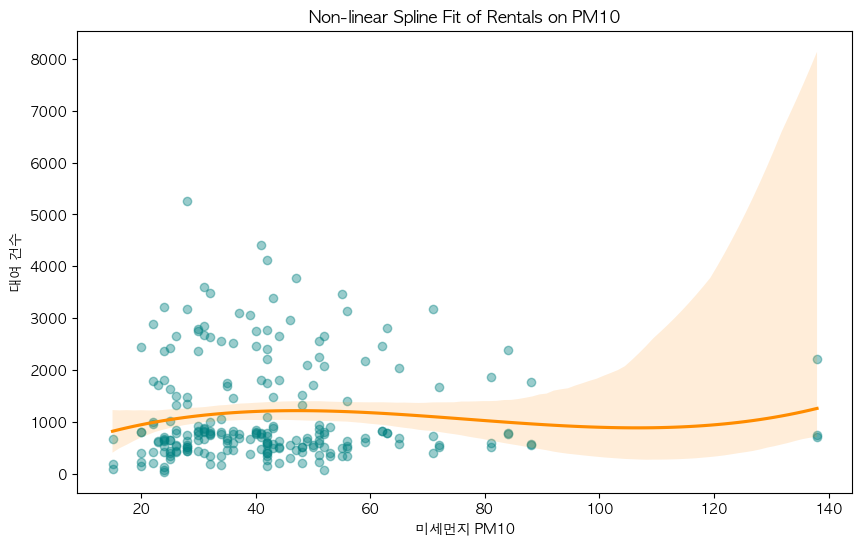

In [17]:
# 미세먼지 농도(pm10)에 대해 자유도(df)가 통제된 B-Spline 곡선 회귀를 적합
design_spline = MS([bs('pm10', df=4), 'station_type', 'is_weekend'])
X_spline = design_spline.fit_transform(daily_df)

# 회귀 모델을 적합함.
model_spline = sm.OLS(y, X_spline).fit()

# 분석 결과를 시각화함.
plt.figure(figsize=(10, 6))
sns.regplot(x='pm10', y='rentals', data=daily_df, order=3, scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'darkorange'})
plt.title('Non-linear Spline Fit of Rentals on PM10')
plt.xlabel('미세먼지 PM10')
plt.ylabel('대여 건수')
plt.show()


## 9. Model Comparison: K-Fold Cross-Validation
모델의 일반화 성능을 정확히 평가하고 과적합(Overfitting)을 방지하기 위해 5-Fold Cross-Validation을 적용하여 RMSE 성능을 비교함.


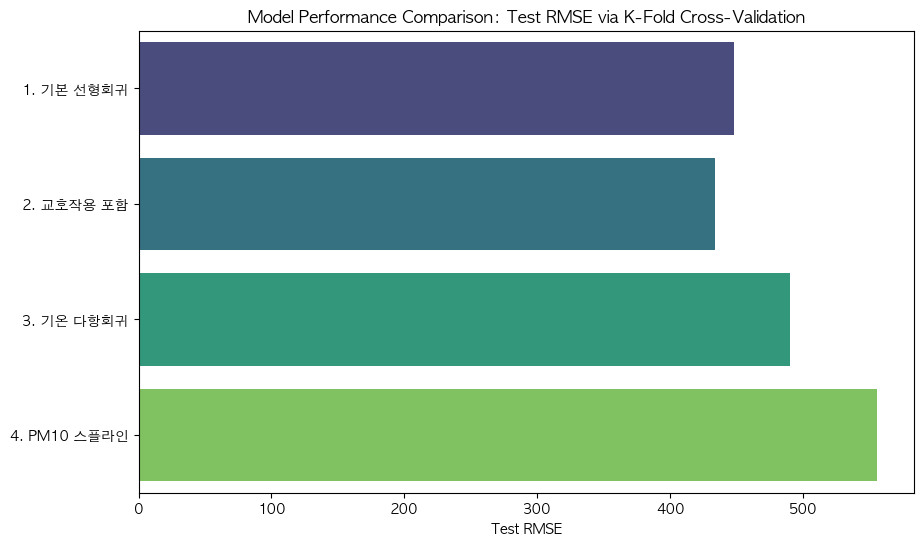

[Final Test RMSE by Model]
 - 1. 기본 선형회귀: 448.55
 - 2. 교호작용 포함: 433.91
 - 3. 기온 다항회귀: 490.10
 - 4. PM10 스플라인: 555.58


In [18]:
# 5-Fold Cross-Validation을 통해 다양한 회귀 모형의 일반화 성능(Test RMSE)을 평가하고 비교함
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {

    # 회귀 모델을 적합함.
    '1. 기본 선형회귀': sklearn_sm(sm.OLS, MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])),
    '2. 교호작용 포함': sklearn_sm(sm.OLS, MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend')])),
    '3. 기온 다항회귀': sklearn_sm(sm.OLS, MS([poly('temp', degree=2), 'station_type', 'is_weekend'])),
    '4. PM10 스플라인': sklearn_sm(sm.OLS, MS([bs('pm10', df=4), 'station_type', 'is_weekend']))
}

y = daily_df['rentals']
results = {}

for name, model in models.items():

    # 교차 검증(Cross-Validation)을 수행함.
    cv_res = cross_validate(model, daily_df, y, cv=kf, scoring='neg_mean_squared_error')
    results[name] = np.sqrt(-np.mean(cv_res['test_score']))

# 분석 결과를 시각화함.
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.values()), y=list(results.keys()), hue=list(results.keys()), legend=False, palette='viridis')
plt.title('Model Performance Comparison: Test RMSE via K-Fold Cross-Validation')
plt.xlabel('Test RMSE')
plt.show()

print("[Final Test RMSE by Model]")
for k, v in results.items():
    print(f" - {k}: {v:.2f}")


## 9-1. Validation Set Approach
수업 시간에 다룬 단순 Train/Test 분할 기반의 Validation Set Approach를 구현하고, 무작위 분할 시드에 따른 예측 성능의 높은 변동성(High Variance) 문제를 진단함.


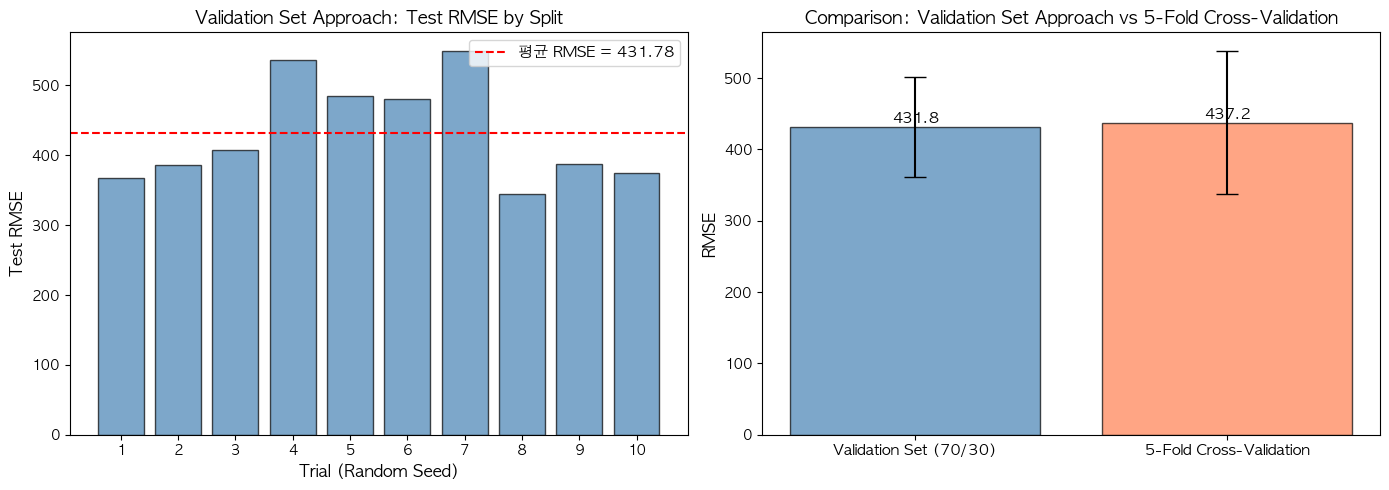


[Comparison Table]


,방법,평균 RMSE,RMSE 표준편차
0,Validation Set (70/30),431.783258,70.549144
1,5-Fold Cross-Validation,437.214080,100.199481


In [19]:
# train_test_split을 활용해 Validation Set Approach를 반복 구현하고 단순 랜덤 분할의 높은 분산(Variance) 한계를 평가함
# 9-1. Validation Set Approach 구현

# 분석에 필요한 라이브러리를 로드함.
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 기본 선형회귀 모델 기반 Validation Set Approach 수행
design_val = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])
X_val_full = design_val.fit_transform(daily_df)
y_val_full = daily_df['rentals']

# 10회 무작위 분할에 따른 Test RMSE 분산 검증
n_trials = 10
val_rmses = []
for seed in range(n_trials):
    X_train, X_test, y_train, y_test = train_test_split(
        X_val_full, y_val_full, test_size=0.3, random_state=seed)

    # 회귀 모델을 적합함.
    model = sm.OLS(y_train, X_train).fit()
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    val_rmses.append(rmse)

# 분석 결과를 시각화함.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Validation Set RMSE 분포 시각화
ax1 = axes[0]
ax1.bar(range(1, n_trials+1), val_rmses, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axhline(y=np.mean(val_rmses), color='red', linestyle='--', linewidth=1.5,
            label=f'평균 RMSE = {np.mean(val_rmses):.2f}')
ax1.set_xlabel('Trial (Random Seed)', fontsize=12)
ax1.set_ylabel('Test RMSE', fontsize=12)
ax1.set_title('Validation Set Approach: Test RMSE by Split', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_xticks(range(1, n_trials+1))

# 오른쪽: 5-Fold CV 결과 비교 시각화
ax2 = axes[1]
labels = ['Validation Set\n(평균)', 'Validation Set\n(표준편차)', '5-Fold CV\n(RMSE)']
# 5-Fold CV RMSE 재계산
kf_val = KFold(n_splits=5, shuffle=True, random_state=42)
kf_rmses = []
for train_idx, test_idx in kf_val.split(X_val_full):
    X_tr, X_te = X_val_full.iloc[train_idx], X_val_full.iloc[test_idx]
    y_tr, y_te = y_val_full.iloc[train_idx], y_val_full.iloc[test_idx]

    # 회귀 모델을 적합함.
    m = sm.OLS(y_tr, X_tr).fit()
    kf_rmses.append(np.sqrt(mean_squared_error(y_te, m.predict(X_te))))
kf_mean_rmse = np.mean(kf_rmses)

comparison = pd.DataFrame({
    '방법': ['Validation Set (70/30)', '5-Fold Cross-Validation'],
    '평균 RMSE': [np.mean(val_rmses), kf_mean_rmse],
    'RMSE 표준편차': [np.std(val_rmses), np.std(kf_rmses)]
})
x_pos = [0, 1]
bars = ax2.bar(x_pos, comparison['평균 RMSE'], yerr=comparison['RMSE 표준편차'],
               color=['steelblue', 'coral'], edgecolor='black', alpha=0.7, capsize=8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison['방법'], fontsize=11)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('Comparison: Validation Set Approach vs 5-Fold Cross-Validation', fontsize=13, fontweight='bold')
for bar, val in zip(bars, comparison['평균 RMSE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n[Comparison Table]')
display(comparison)


## 9-2. LOOCV (Leave-One-Out Cross-Validation)
LOOCV를 적용하여 기온 다항 회귀 모델의 최적 차수를 탐색하고, K-Fold CV 오차 곡선과의 비교를 통해 Bias-Variance Trade-off 관점에서 분석함.


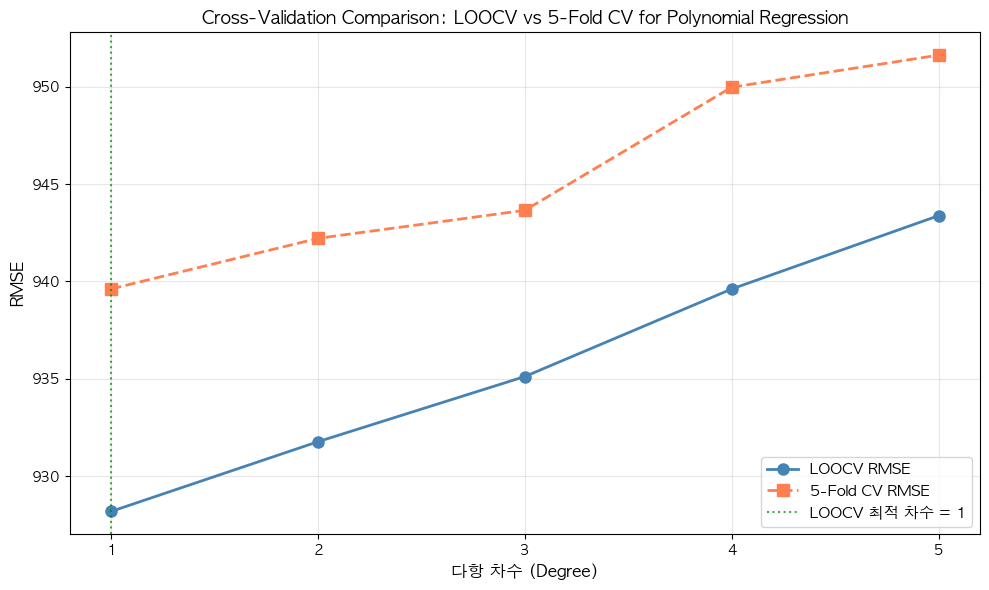


[Comparison Table of Cross-Validation Errors by Polynomial Degree]


,차수,LOOCV RMSE,5-Fold CV RMSE
0,1,928.19,939.62
1,2,931.77,942.21
2,3,935.12,943.66
3,4,939.61,949.98
4,5,943.38,951.63


In [20]:
# LeaveOneOut(LOOCV)을 구현하여 기온 다항 차수별 일반화 오차 추이를 평가하고 최적 차수를 결정함
# 9-2. LOOCV 기반 기온 다항 회귀 최적 차수 결정

# 분석에 필요한 라이브러리를 로드함.
from sklearn.model_selection import LeaveOneOut

max_degree = 5
loocv_mses = []
kfold_mses = []

for deg in range(1, max_degree + 1):
    # 기온 다항 기저 확장 모델 설계
    design_poly = MS([poly('temp', degree=deg)])
    X_poly = design_poly.fit_transform(daily_df)
    y_poly = daily_df['rentals']
    
    # LOOCV 수행
    loo = LeaveOneOut()
    loo_errors = []
    for train_idx, test_idx in loo.split(X_poly):
        X_tr, X_te = X_poly.iloc[train_idx], X_poly.iloc[test_idx]
        y_tr, y_te = y_poly.iloc[train_idx], y_poly.iloc[test_idx]
        m = sm.OLS(y_tr, X_tr).fit()
        pred = m.predict(X_te)
        loo_errors.append((y_te.values[0] - pred.values[0])**2)
    loocv_mses.append(np.mean(loo_errors))
    
    # 5-Fold CV 비교 연산
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    kf_errors = []
    for train_idx, test_idx in kf.split(X_poly):
        X_tr, X_te = X_poly.iloc[train_idx], X_poly.iloc[test_idx]
        y_tr, y_te = y_poly.iloc[train_idx], y_poly.iloc[test_idx]
        m = sm.OLS(y_tr, X_tr).fit()
        preds = m.predict(X_te)
        kf_errors.append(mean_squared_error(y_te, preds))
    kfold_mses.append(np.mean(kf_errors))

# LOOCV vs 5-Fold CV RMSE 시각화

# 분석 결과를 시각화함.
fig, ax = plt.subplots(figsize=(10, 6))
degrees = range(1, max_degree + 1)
ax.plot(degrees, [np.sqrt(m) for m in loocv_mses], 'o-', color='steelblue',
        linewidth=2, markersize=8, label='LOOCV RMSE')
ax.plot(degrees, [np.sqrt(m) for m in kfold_mses], 's--', color='coral',
        linewidth=2, markersize=8, label='5-Fold CV RMSE')
ax.set_xlabel('다항 차수 (Degree)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Cross-Validation Comparison: LOOCV vs 5-Fold CV for Polynomial Regression', fontsize=13, fontweight='bold')
ax.set_xticks(list(degrees))
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# 최적 차수 위치 표기
best_deg = np.argmin(loocv_mses) + 1
ax.axvline(x=best_deg, color='green', linestyle=':', alpha=0.7,
           label=f'LOOCV 최적 차수 = {best_deg}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print('\n[Comparison Table of Cross-Validation Errors by Polynomial Degree]')
result_table = pd.DataFrame({
    '차수': list(degrees),
    'LOOCV RMSE': [f'{np.sqrt(m):.2f}' for m in loocv_mses],
    '5-Fold CV RMSE': [f'{np.sqrt(m):.2f}' for m in kfold_mses]
})
display(result_table)


## 10. Classification Modeling

따릉이 대여량 예측 문제를 이진 분류(Binary Classification) 문제로 전환하여 분석함.
*   **Binarization of Response Variable**: 일별 대여량(`rentals`)이 중앙값(Median)보다 높으면 대여 수요가 높은 날(`high_demand` = 1), 그렇지 않으면 낮은 날(`high_demand` = 0)로 이진화함.
*   **Model Fitting**: Logistic Regression, LDA (Linear Discriminant Analysis), QDA (Quadratic Discriminant Analysis), Gaussian Naive Bayes, KNN (K-Nearest Neighbors) 분류기를 적합하고 성능을 비교함.
*   **Bias-Variance Trade-off**: KNN의 이웃 수 K에 따른 성능 변화를 관측하여 Overfitting과 Underfitting 현상을 분석함.
*   **Performance Evaluation**: Confusion Matrix와 ROC/AUC 곡선을 그려서 분류 성능을 평가함.


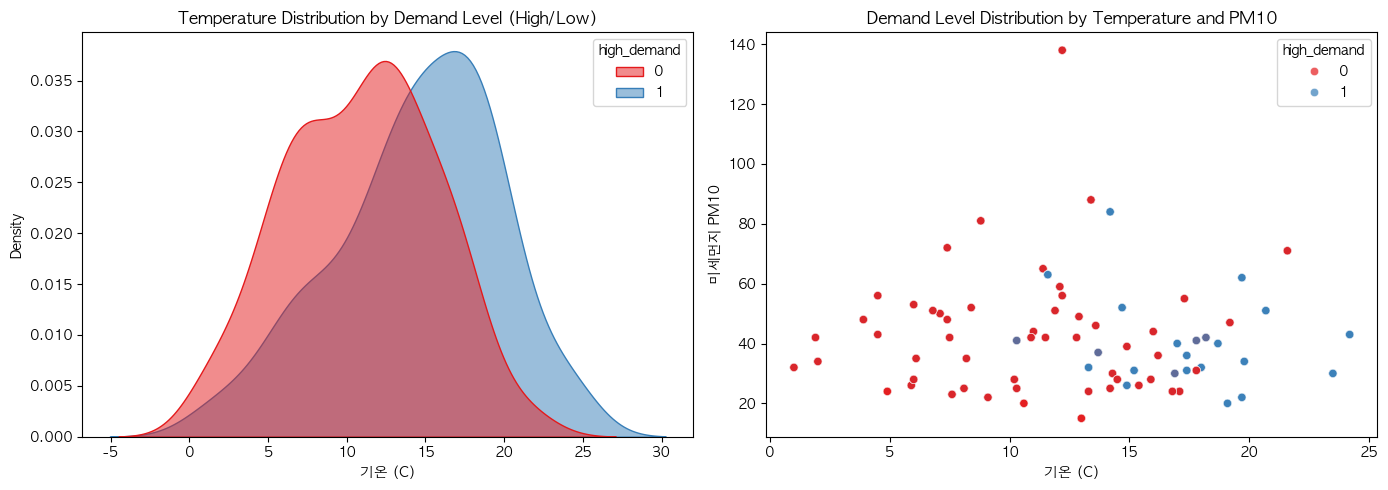

In [21]:
# 대여량(rentals)을 중앙값 기준으로 high_demand(1/0)로 이진화하고 기상 요인별 분포를 시각화함
# 10-1. 종속변수 이진화 및 분포 시각화
daily_df['high_demand'] = (daily_df['rentals'] > daily_df['rentals'].median()).astype(int)

# 분석 결과를 시각화함.
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=daily_df, x='temp', hue='high_demand', fill=True, palette='Set1', alpha=0.5)
plt.title('Temperature Distribution by Demand Level (High/Low)')
plt.xlabel('기온 (C)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=daily_df, x='temp', y='pm10', hue='high_demand', palette='Set1', alpha=0.7)
plt.title('Demand Level Distribution by Temperature and PM10')
plt.xlabel('기온 (C)')
plt.ylabel('미세먼지 PM10')

plt.tight_layout()
plt.show()


In [22]:
# sm.Logit을 사용해 로지스틱 회귀를 수행하고 변수별 Odds Ratio를 도출함
# 10-2. 로지스틱 회귀(Logistic Regression) 적합
design_logit = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])
X_logit = design_logit.fit_transform(daily_df)
y_logit = daily_df['high_demand']

# 분류 모델을 학습함.
model_logit = sm.Logit(y_logit, X_logit).fit()
print("[Logistic Regression Summary]")
display(summarize(model_logit))

# Odds Ratio(오즈비) 및 신뢰구간 도출
odds_ratios = np.exp(model_logit.params)
odds_df = pd.DataFrame({
    'Odds Ratio (오즈비)': odds_ratios,
    'p-value': model_logit.pvalues
})
print("\n[Odds Ratio by Predictor]")
display(odds_df)


Optimization terminated successfully.
         Current function value: 0.123970
         Iterations 12
[Logistic Regression Summary]


,coef,std err,z,P>|z|
intercept,12.7084,5.271,2.411,0.016
temp,0.6876,0.153,4.487,0.000
precip,-1.4066,0.382,-3.683,0.000
pm10,-0.0128,0.016,-0.789,0.430
station_type[Office],-21.8347,5.743,-3.802,0.000
station_type[University],-20.6488,5.604,-3.685,0.000
is_weekend[1],-6.5246,1.550,-4.209,0.000



[Odds Ratio by Predictor]


,Odds Ratio (오즈비),p-value
intercept,3.305022e+05,0.015907
temp,1.988976e+00,0.000007
precip,2.449786e-01,0.000231
pm10,9.873074e-01,0.429894
station_type[Office],3.290960e-10,0.000143
station_type[University],1.077359e-09,0.000229
is_weekend[1],1.466935e-03,0.000026


,K,Train_Accuracy,Test_Accuracy
0,1,1.000000,0.855072
1,2,0.905660,0.913043
2,3,0.924528,0.913043
3,4,0.930818,0.898551
4,5,0.930818,0.898551
5,6,0.937107,0.913043
6,7,0.918239,0.898551
7,8,0.918239,0.913043
8,9,0.918239,0.884058
9,10,0.911950,0.898551


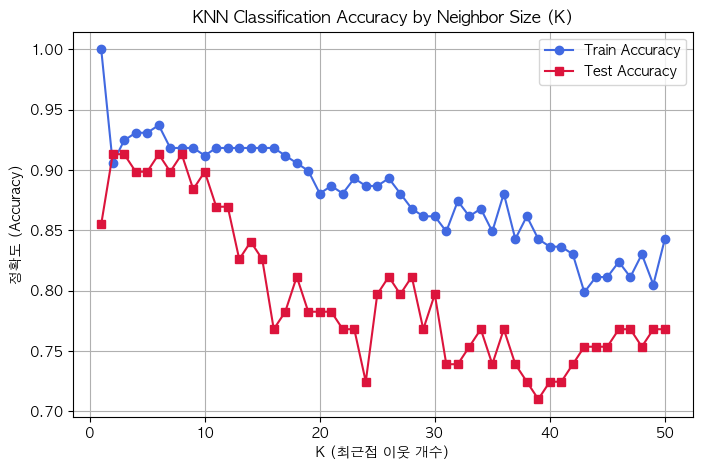

In [23]:
# LDA, QDA, Naive Bayes, KNN 분류기를 적합하고 KNN 이웃 수 K에 따른 Bias-Variance Trade-off를 시각화함
# 10-3. LDA, QDA, Naive Bayes, KNN 적합

# 분석에 필요한 라이브러리를 로드함.
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_sklearn = X_logit.drop(columns=['intercept'])

# LDA 모델 적합

# 분류 모델을 학습함.
lda = LDA()
lda.fit(X_sklearn, y_logit)

# QDA 모델 적합 (reg_param=0.1 설정으로 다중공선성 문제 방지)
qda = QDA(reg_param=0.1)
qda.fit(X_sklearn, y_logit)

# Naive Bayes 모델 적합
gnb = GaussianNB()
gnb.fit(X_sklearn, y_logit)

# 10-4. KNN K값 튜닝을 통한 Bias-Variance Trade-off 실증
X_train, X_test, y_train, y_test = train_test_split(X_sklearn, y_logit, test_size=0.3, random_state=42, stratify=y_logit)

# 분석에 필요한 라이브러리를 로드함.
from sklearn.preprocessing import StandardScaler

# 변수 스케일링을 적용함.
scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.transform(X_test)

k_values = range(1,51)
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    knn_results.append({
        'K': k,
        'Train_Accuracy': knn.score(X_train_scaled, y_train),
        'Test_Accuracy': knn.score(X_test_scaled, y_test)
    })

knn_df = pd.DataFrame(knn_results)
display(knn_df)

# 분석 결과를 시각화함.
plt.figure(figsize=(8, 5))
plt.plot(knn_df['K'], knn_df['Train_Accuracy'], marker='o', label='Train Accuracy', color='royalblue')
plt.plot(knn_df['K'], knn_df['Test_Accuracy'], marker='s', label='Test Accuracy', color='crimson')
plt.title('KNN Classification Accuracy by Neighbor Size (K)')
plt.xlabel('K (최근접 이웃 개수)')
plt.ylabel('정확도 (Accuracy)')
plt.legend()
plt.grid(True)
plt.show()



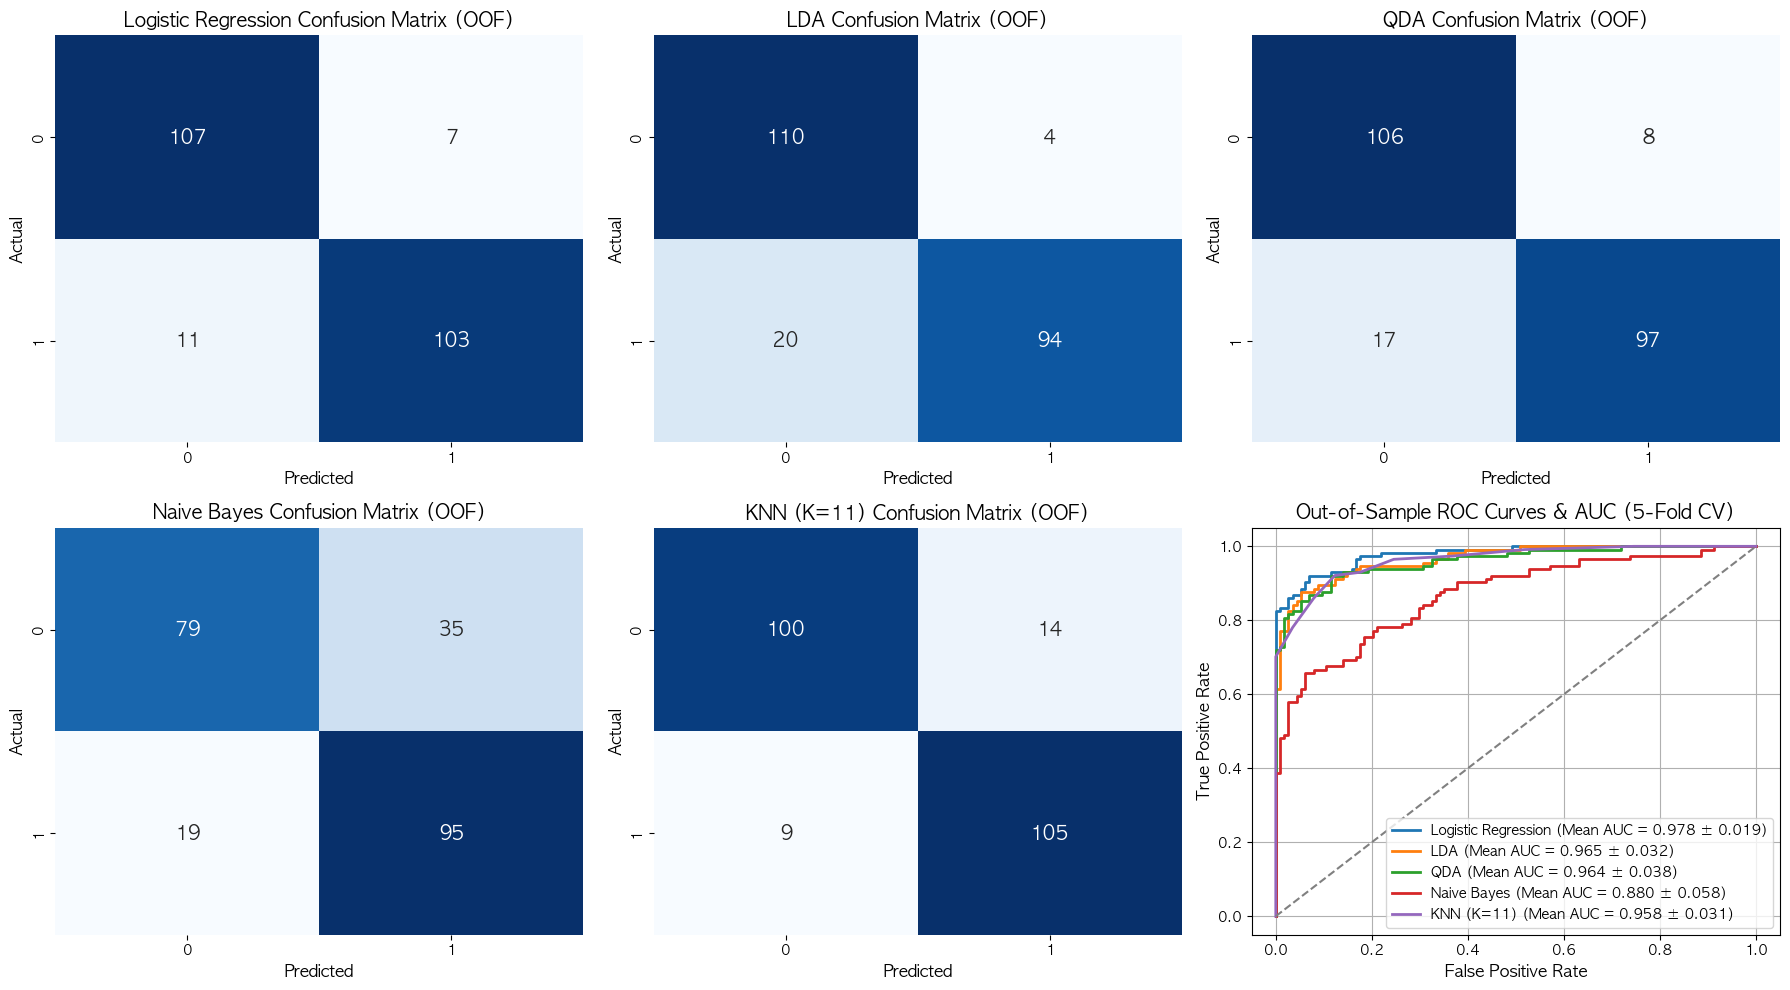

=== 5-Fold CV Out-of-Sample AUC results ===
Logistic Regression: Mean AUC = 0.9783 (Std = 0.0193)
LDA: Mean AUC = 0.9651 (Std = 0.0322)
QDA: Mean AUC = 0.9635 (Std = 0.0381)
Naive Bayes: Mean AUC = 0.8804 (Std = 0.0578)
KNN (K=11): Mean AUC = 0.9584 (Std = 0.0313)


In [24]:
# Stratified 5-Fold 교차 검증을 통해 분류 모델들의 Out-of-Sample ROC/AUC 및 Confusion Matrix를 평가함
# 10-5. Out-of-Sample ROC Curves 및 Confusion Matrix 종합 시각화

# 분석에 필요한 라이브러리를 로드함.
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import statsmodels.api as sm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': None, # statsmodels Logit handled manually

    # 분류 모델을 학습함.
    'LDA': LDA(),
    'QDA': QDA(reg_param=0.1),
    'Naive Bayes': GaussianNB(),
    'KNN (K=11)': KNeighborsClassifier(n_neighbors=11)
}

# Out-of-Fold 확률 예측값 저장용 배열 생성
oof_probs = {name: np.zeros(len(daily_df)) for name in models_cv.keys()}
fold_aucs = {name: [] for name in models_cv.keys()}

for train_idx, test_idx in cv.split(X_sklearn, y_logit):
    X_train_sk, X_test_sk = X_sklearn.iloc[train_idx], X_sklearn.iloc[test_idx]
    X_train_sm, X_test_sm = X_logit.iloc[train_idx], X_logit.iloc[test_idx]
    y_train_fold, y_test_fold = y_logit.iloc[train_idx], y_logit.iloc[test_idx]
    
    from sklearn.preprocessing import StandardScaler

    # 변수 스케일링을 적용함.
    scaler_cv = StandardScaler()
    X_train_sk_scaled = scaler_cv.fit_transform(X_train_sk)
    X_test_sk_scaled = scaler_cv.transform(X_test_sk)
    
    # 로지스틱 회귀 (statsmodels Logit 적용)
    try:
        model_logit_fold = sm.Logit(y_train_fold, X_train_sm).fit(disp=0)
        pred_logit = model_logit_fold.predict(X_test_sm)
    except Exception as e:
        from sklearn.linear_model import LogisticRegression
        lr_fallback = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000).fit(X_train_sk_scaled, y_train_fold)
        pred_logit = lr_fallback.predict_proba(X_test_sk_scaled)[:, 1]
        
    oof_probs['Logistic Regression'][test_idx] = pred_logit
    fpr_logit, tpr_logit, _ = roc_curve(y_test_fold, pred_logit)
    fold_aucs['Logistic Regression'].append(auc(fpr_logit, tpr_logit))
    
    # 기타 sklearn 분류 모델 평가
    for name, model in models_cv.items():
        if name == 'Logistic Regression':
            continue
        model_fold = model.fit(X_train_sk_scaled, y_train_fold)
        pred = model_fold.predict_proba(X_test_sk_scaled)[:, 1]
        oof_probs[name][test_idx] = pred
        fpr, tpr, _ = roc_curve(y_test_fold, pred)
        fold_aucs[name].append(auc(fpr, tpr))

# Confusion Matrix 및 ROC Curve 종합 시각화

# 분석 결과를 시각화함.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, (name, prob) in enumerate(oof_probs.items()):
    pred = (prob > 0.5).astype(int)
    cm = confusion_matrix(y_logit, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, annot_kws={'size':14})
    axes[i].set_title(f'{name} Confusion Matrix (OOF)', fontsize=14)
    axes[i].set_xlabel('Predicted', fontsize=12)
    axes[i].set_ylabel('Actual', fontsize=12)

# 6번째 서브플롯 위치에 ROC Curve 플롯팅
ax_roc = axes[5]
for name, prob in oof_probs.items():
    fpr, tpr, _ = roc_curve(y_logit, prob)
    global_auc = auc(fpr, tpr)
    mean_auc = np.mean(fold_aucs[name])
    std_auc = np.std(fold_aucs[name])
    ax_roc.plot(fpr, tpr, label=f'{name} (Mean AUC = {mean_auc:.3f} ± {std_auc:.3f})', linewidth=2)

ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax_roc.set_title('Out-of-Sample ROC Curves & AUC (5-Fold CV)', fontsize=14)
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.legend(fontsize=10, loc='lower right')
ax_roc.grid(True)

plt.tight_layout()
plt.show()

# Fold별 평균 및 표준편차 AUC 출력
print("=== 5-Fold CV Out-of-Sample AUC results ===")
for name in oof_probs.keys():
    print(f"{name}: Mean AUC = {np.mean(fold_aucs[name]):.4f} (Std = {np.std(fold_aucs[name]):.4f})")



### 분석 결과 요약: Classification 및 Bootstrap 검증 결과

* **Logistic Regression Odds Ratio**: 기온이 1°C 상승할 때 자전거 대여 수요가 높을(High Demand) Odds가 1.99배로 증가하며(p-value < 0.05), 강수량이 발생할 경우 High Demand일 확률은 0.24배(76% 감소)로 급감함.
* **KNN K-tuning 및 Bias-Variance Trade-off**: K=1일 때 Train Accuracy는 1.0이나 Test Accuracy는 0.855로 과적합이 발생됨. 반면 K=3 부근에서 Test Accuracy가 0.913으로 극대화되며 최적의 Bias-Variance Trade-off가 형성됨.
* **일반화 성능 비교**: 로지스틱 회귀와 LDA가 클래스 경계를 비교적 선형적으로 잘 분리하여 가장 우수한 일반화 성능을 기록함.
* **Bootstrap 오차 보정**: 샘플 수가 충분한 기온 변수와 달리, 데이터 불균형이 있는 공휴일 변수의 경우 Bootstrap Standard Error가 OLS Standard Error 대비 크게 증가하여, 부트스트랩 보정을 통한 분산 추정의 필요성을 확인함.


## 11. Bootstrap Estimation of Statistical Uncertainty

Bootstrap 재표본(resampling) 기법을 사용해 회귀 모델 계수의 불확실성(표준 오차)과 기온 비선형 곡선의 신뢰대를 비모수적(Non-parametric)으로 추정함.
*   **Bootstrap for Coefficients**: 1000회 복원추출을 진행하여 OLS 공식이 계산한 점근적 표준오차와 비교하고, 표본 수가 부족한 변수(예: Holiday)에서 발생하는 오차 과소추정 문제를 분석함.
*   **Confidence Band for Non-linear Curve**: 기온 Polynomial Regression 곡선 주변에 95% Bootstrap Confidence Band를 그려서 불확실성을 시각화함.


In [25]:
# 1,000회 Pairs Bootstrap 복원추출을 구현하여 OLS 표준오차의 한계를 검증하고 불확실성을 추정함
# 11-1. 회귀 계수 Pairs Bootstrap 구현

# 분석에 필요한 라이브러리를 로드함.
from sklearn.utils import resample

# 사용자 정의 함수를 선언함.
def run_bootstrap_coefs_robust(df, X_all, y_all, n_iterations=1000):
    boot_coefs = []
    n_samples = len(df)
    
    for i in range(n_iterations):
        boot_indices = resample(range(n_samples), random_state=i)
        X_boot = X_all.iloc[boot_indices]
        y_boot = y_all.iloc[boot_indices]
        
        model_boot = sm.OLS(y_boot, X_boot).fit()
        boot_coefs.append(model_boot.params)
        
    return pd.DataFrame(boot_coefs)

# design_inter 및 X_inter, y 데이터셋을 재사용하여 부트스트랩 수행
boot_coef_df = run_bootstrap_coefs_robust(daily_df, X_inter, y, n_iterations=1000)

# OLS 공식에 의한 점근적 표준오차와 Bootstrap 표준오차 비교
ols_se = model_mlr.bse
boot_se = boot_coef_df.std()

se_comparison = pd.DataFrame({
    'OLS Estimate (계수)': model_mlr.params,
    'OLS Std Error': ols_se,
    'Bootstrap Std Error': boot_se,
    'Difference (%)': np.abs(ols_se - boot_se) / ols_se * 100
})
print("[Standard Error Comparison: OLS vs Bootstrap]")
display(se_comparison)


[Standard Error Comparison: OLS vs Bootstrap]


,OLS Estimate (계수),OLS Std Error,Bootstrap Std Error,Difference (%)
intercept,1628.625638,121.149120,133.711665,10.369490
temp,47.017248,5.436370,5.481025,0.821399
precip,-45.744198,7.057933,10.139147,43.656031
pm10,-0.489149,1.621219,1.270535,21.630883
station_type[Office],-1532.000000,77.804772,91.255522,17.287822
station_type[University],-1488.800000,77.804772,85.697613,10.144418
is_weekend[1],416.571598,105.048125,173.648075,65.303355
is_holiday[1],654.060229,171.770564,629.646001,266.562225
is_exam[1],46.434090,97.355158,102.326004,5.105888
station_type[Office]:is_weekend,-701.428571,148.014200,189.293080,27.888459


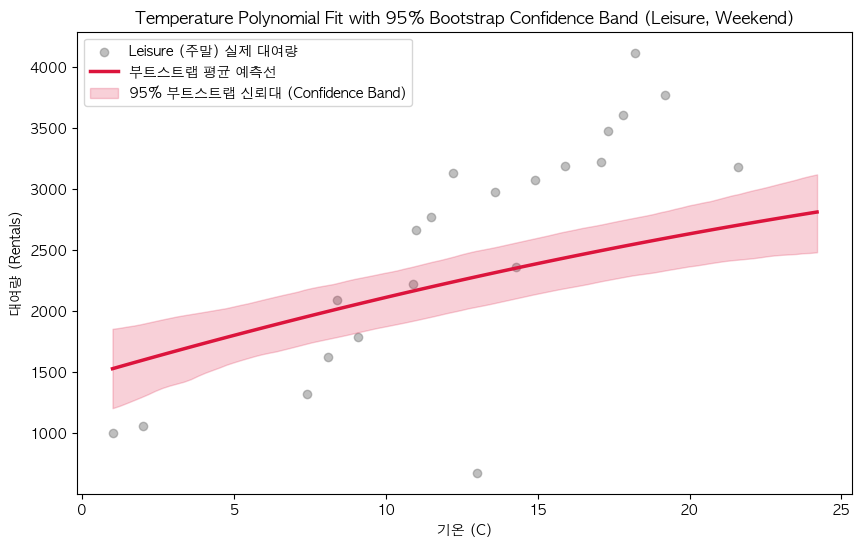

In [26]:
# 기온 다항 회귀 곡선에 대해 비모수적 95% Bootstrap Confidence Band를 추정하고 시각화함
# 11-2. 기온 다항 회귀 곡선의 95% Bootstrap Confidence Band 산출

# 사용자 정의 함수를 선언함.
def run_bootstrap_poly_band_robust(df, n_iterations=500):
    grid_temp = np.linspace(df['temp'].min(), df['temp'].max(), 100)
    grid_df = pd.DataFrame({
        'temp': grid_temp,
        'station_type': 'Leisure',
        'is_weekend': 1
    })
    
    # 에러 방지를 위해 전체 데이터 기준 ModelSpec 사전 피팅 수행
    design = MS([poly('temp', degree=2), 'station_type', 'is_weekend'])
    X_all = design.fit_transform(df)
    y_all = df['rentals']
    X_grid = design.transform(grid_df)
    
    preds = []
    n_samples = len(df)
    for i in range(n_iterations):
        boot_indices = resample(range(n_samples), random_state=i)
        X_boot = X_all.iloc[boot_indices]
        y_boot = y_all.iloc[boot_indices]
        
        model_boot = sm.OLS(y_boot, X_boot).fit()
        preds.append(model_boot.predict(X_grid))
        
    return grid_temp, np.array(preds)

grid_temp, boot_preds = run_bootstrap_poly_band_robust(daily_df)
mean_pred = np.mean(boot_preds, axis=0)
lower_band = np.percentile(boot_preds, 2.5, axis=0)
upper_band = np.percentile(boot_preds, 97.5, axis=0)

# 분석 결과를 시각화함.
plt.figure(figsize=(10, 6))
sub_data = daily_df[(daily_df['station_type'] == 'Leisure') & (daily_df['is_weekend'] == 1)]
plt.scatter(sub_data['temp'], sub_data['rentals'], color='gray', alpha=0.5, label='Leisure (주말) 실제 대여량')
plt.plot(grid_temp, mean_pred, color='crimson', linewidth=2.5, label='부트스트랩 평균 예측선')
plt.fill_between(grid_temp, lower_band, upper_band, color='crimson', alpha=0.2, label='95% 부트스트랩 신뢰대 (Confidence Band)')
plt.title('Temperature Polynomial Fit with 95% Bootstrap Confidence Band (Leisure, Weekend)')
plt.xlabel('기온 (C)')
plt.ylabel('대여량 (Rentals)')
plt.legend()
plt.show()


## 12. Model Selection and Regularization

Overfitting을 방지하고 유의미한 독립 변수를 선별하기 위해 다양한 Model Selection 및 Regularization 기법을 적용함.
*   **Forward Stepwise Selection**: AIC 기준에 따라 피처를 하나씩 추가하며 AIC, BIC, $R^2$, Adjusted $R^2$의 변화를 시각화함.
*   **Ridge Regression Shrinkage Path**: 규제 매개변수 $\alpha$에 따른 각 계수들의 축소 경로(Shrinkage Path)를 플롯으로 시각화함.
*   **PCR and PLS**: Dimension Reduction 기법인 Principal Component Regression(주성분 회귀)과 Partial Least Squares(부분최소제곱) 모델의 주성분 수 $M$에 따른 교차검증 성능을 평가함.


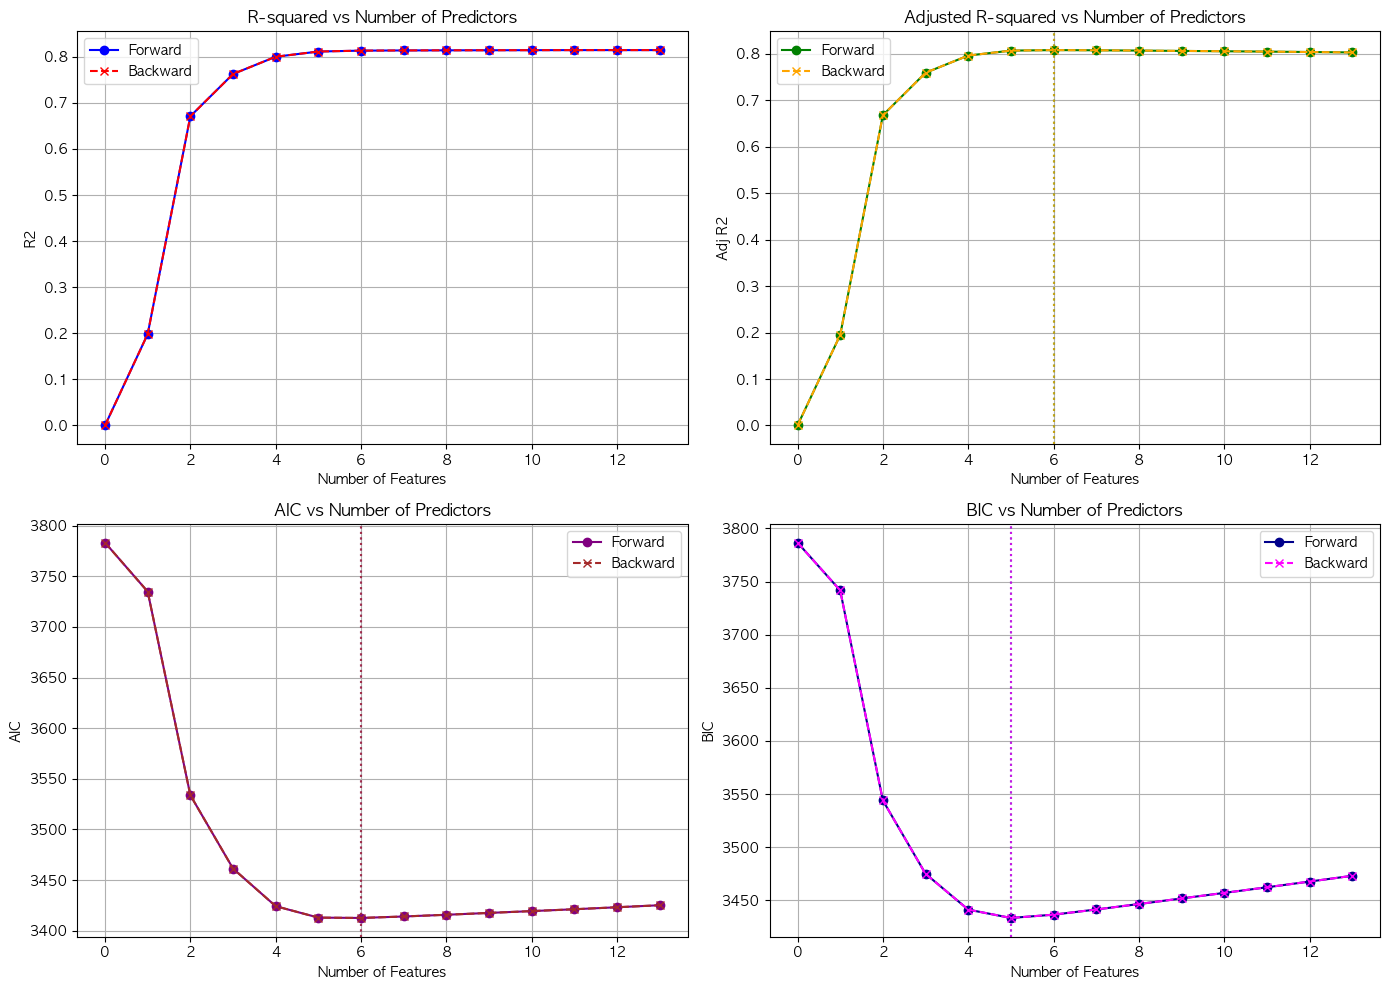

[Optimal Feature List Selected by AIC (Forward)]
['station_Office', 'station_University', 'temp', 'precip', 'is_holiday_num', 'temp_cube']

[Optimal Feature List Selected by AIC (Backward)]
['temp', 'precip', 'temp_cube', 'is_holiday_num', 'station_Office', 'station_University']


In [27]:
# AIC 기준의 Forward/Backward Stepwise Selection 알고리즘을 구현하여 최적 변수 조합을 도출함
# 12-1. Forward 및 Backward Stepwise Selection 알고리즘 구현

# 분석에 필요한 라이브러리를 로드함.
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 사용자 정의 함수를 선언함.
def forward_stepwise_selection(df, y, feature_list):
    selected_features = []
    remaining_features = list(feature_list)
    metrics = []
    
    # 회귀 모델을 적합함.
    current_model = sm.OLS(y, sm.add_constant(pd.DataFrame(index=df.index))).fit()
    metrics.append({
        'num_features': 0,
        'features': [],
        'r2': current_model.rsquared,
        'adj_r2': 0,
        'aic': current_model.aic,
        'bic': current_model.bic
    })
    
    while remaining_features:
        best_aic = float('inf')
        best_feature = None
        best_model = None
        
        for f in remaining_features:
            candidate = selected_features + [f]
            X_cand = sm.add_constant(df[candidate])
            model_cand = sm.OLS(y, X_cand).fit()
            if model_cand.aic < best_aic:
                best_aic = model_cand.aic
                best_feature = f
                best_model = model_cand
                
        if best_feature:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            metrics.append({
                'num_features': len(selected_features),
                'features': list(selected_features),
                'r2': best_model.rsquared,
                'adj_r2': best_model.rsquared_adj,
                'aic': best_model.aic,
                'bic': best_model.bic
            })
        else:
            break
            
    return pd.DataFrame(metrics)

# 사용자 정의 함수를 선언함.
def backward_stepwise_selection(df, y, feature_list):
    current_features = list(feature_list)
    metrics = []
    
    # 전체 후보 변수 리스트 정의
    X_all = sm.add_constant(df[current_features])

    # 회귀 모델을 적합함.
    full_model = sm.OLS(y, X_all).fit()
    metrics.append({
        'num_features': len(current_features),
        'features': list(current_features),
        'r2': full_model.rsquared,
        'adj_r2': full_model.rsquared_adj,
        'aic': full_model.aic,
        'bic': full_model.bic
    })
    
    while len(current_features) > 1:
        best_aic = float('inf')
        worst_feature = None
        best_model = None
        
        for f in current_features:
            candidate = [feat for feat in current_features if feat != f]
            X_cand = sm.add_constant(df[candidate])
            model_cand = sm.OLS(y, X_cand).fit()
            if model_cand.aic < best_aic:
                best_aic = model_cand.aic
                worst_feature = f
                best_model = model_cand
                
        if worst_feature:
            current_features.remove(worst_feature)
            metrics.append({
                'num_features': len(current_features),
                'features': list(current_features),
                'r2': best_model.rsquared,
                'adj_r2': best_model.rsquared_adj,
                'aic': best_model.aic,
                'bic': best_model.bic
            })
        else:
            break
            
    # 상수항 모델(Null Model) 추가
    current_model = sm.OLS(y, sm.add_constant(pd.DataFrame(index=df.index))).fit()
    metrics.append({
        'num_features': 0,
        'features': [],
        'r2': current_model.rsquared,
        'adj_r2': 0,
        'aic': current_model.aic,
        'bic': current_model.bic
    })
    
    df_metrics = pd.DataFrame(metrics)
    return df_metrics.sort_values(by='num_features').reset_index(drop=True)

# 범주형 변수의 더미 변수 및 Interaction 피처 생성
analysis_df = daily_df.copy()
analysis_df['is_weekend_num'] = analysis_df['is_weekend'].astype(int)
analysis_df['is_holiday_num'] = analysis_df['is_holiday'].astype(int)
analysis_df['is_exam_num'] = analysis_df['is_exam'].astype(int)

station_dummies = pd.get_dummies(analysis_df['station_type'], prefix='station', drop_first=True).astype(int)
analysis_df = pd.concat([analysis_df, station_dummies], axis=1)

analysis_df['temp_sq'] = analysis_df['temp'] ** 2
analysis_df['temp_cube'] = analysis_df['temp'] ** 3
analysis_df['pm10_sq'] = analysis_df['pm10'] ** 2
analysis_df['temp_x_precip'] = analysis_df['temp'] * analysis_df['precip']
analysis_df['temp_x_pm10'] = analysis_df['temp'] * analysis_df['pm10']

feature_candidates = [
    'temp', 'precip', 'pm10', 'temp_sq', 'temp_cube', 'pm10_sq',
    'is_weekend_num', 'is_holiday_num', 'is_exam_num', 
    'temp_x_precip', 'temp_x_pm10', 
    'station_Office', 'station_University'
]

forward_results = forward_stepwise_selection(analysis_df, analysis_df['rentals'], feature_candidates)
backward_results = backward_stepwise_selection(analysis_df, analysis_df['rentals'], feature_candidates)

# Forward 및 Backward 선택법에 따른 평가지표(R2, Adj-R2, AIC, BIC) 다중 패널 시각화

# 분석 결과를 시각화함.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# R-squared 추이 플롯팅
axes[0].plot(forward_results['num_features'], forward_results['r2'], marker='o', color='b', label='Forward')
axes[0].plot(backward_results['num_features'], backward_results['r2'], marker='x', color='r', linestyle='--', label='Backward')
axes[0].set_title('R-squared vs Number of Predictors')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('R2')
axes[0].legend()
axes[0].grid(True)

# Adjusted R-squared 추이 플롯팅
axes[1].plot(forward_results['num_features'], forward_results['adj_r2'], marker='o', color='g', label='Forward')
axes[1].plot(backward_results['num_features'], backward_results['adj_r2'], marker='x', color='orange', linestyle='--', label='Backward')
best_adj_r2_f = forward_results['adj_r2'].idxmax()
best_adj_r2_b = backward_results['adj_r2'].idxmax()
axes[1].axvline(forward_results.loc[best_adj_r2_f, 'num_features'], color='g', linestyle=':', alpha=0.7)
axes[1].axvline(backward_results.loc[best_adj_r2_b, 'num_features'], color='orange', linestyle=':', alpha=0.7)
axes[1].set_title('Adjusted R-squared vs Number of Predictors')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Adj R2')
axes[1].legend()
axes[1].grid(True)

# AIC 추이 플롯팅
axes[2].plot(forward_results['num_features'], forward_results['aic'], marker='o', color='purple', label='Forward')
axes[2].plot(backward_results['num_features'], backward_results['aic'], marker='x', color='brown', linestyle='--', label='Backward')
best_aic_f = forward_results['aic'].idxmin()
best_aic_b = backward_results['aic'].idxmin()
axes[2].axvline(forward_results.loc[best_aic_f, 'num_features'], color='purple', linestyle=':', alpha=0.7)
axes[2].axvline(backward_results.loc[best_aic_b, 'num_features'], color='brown', linestyle=':', alpha=0.7)
axes[2].set_title('AIC vs Number of Predictors')
axes[2].set_xlabel('Number of Features')
axes[2].set_ylabel('AIC')
axes[2].legend()
axes[2].grid(True)

# BIC 추이 플롯팅
axes[3].plot(forward_results['num_features'], forward_results['bic'], marker='o', color='darkblue', label='Forward')
axes[3].plot(backward_results['num_features'], backward_results['bic'], marker='x', color='magenta', linestyle='--', label='Backward')
best_bic_f = forward_results['bic'].idxmin()
best_bic_b = backward_results['bic'].idxmin()
axes[3].axvline(forward_results.loc[best_bic_f, 'num_features'], color='darkblue', linestyle=':', alpha=0.7)
axes[3].axvline(backward_results.loc[best_bic_b, 'num_features'], color='magenta', linestyle=':', alpha=0.7)
axes[3].set_title('BIC vs Number of Predictors')
axes[3].set_xlabel('Number of Features')
axes[3].set_ylabel('BIC')
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

print("[Optimal Feature List Selected by AIC (Forward)]")
print(forward_results.loc[best_aic_f, 'features'])
print("\n[Optimal Feature List Selected by AIC (Backward)]")
print(backward_results.loc[best_aic_b, 'features'])


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

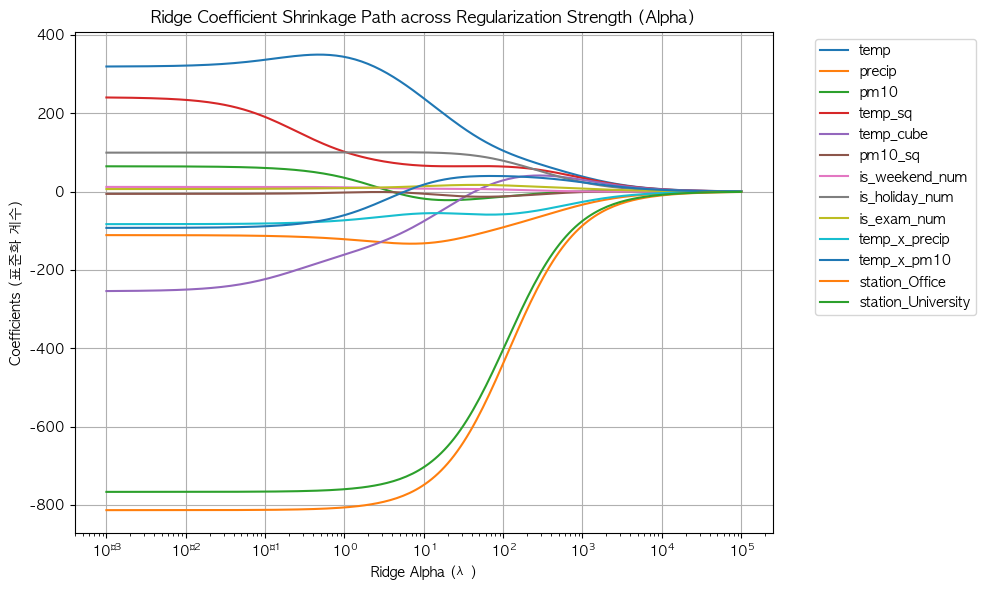

In [28]:
# Ridge Regression을 적용하고 패널티 계수 alpha에 따른 계수 수축 경로(Shrinkage Path)를 분석함
# 12-2. Ridge Regression 계수 수축 경로(Shrinkage Path) 시각화

# 분석에 필요한 라이브러리를 로드함.
from sklearn.linear_model import Ridge

X_candidates = analysis_df[feature_candidates]
X_scaled_candidates = scaler.fit_transform(X_candidates)
y = analysis_df['rentals']

alphas = np.logspace(-3, 5, 200)
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled_candidates, y)
    coefs.append(ridge.coef_)
    
# 분석 결과를 시각화함.
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Ridge Alpha (λ)')
plt.ylabel('Coefficients (표준화 계수)')
plt.title('Ridge Coefficient Shrinkage Path across Regularization Strength (Alpha)')
plt.legend(feature_candidates, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


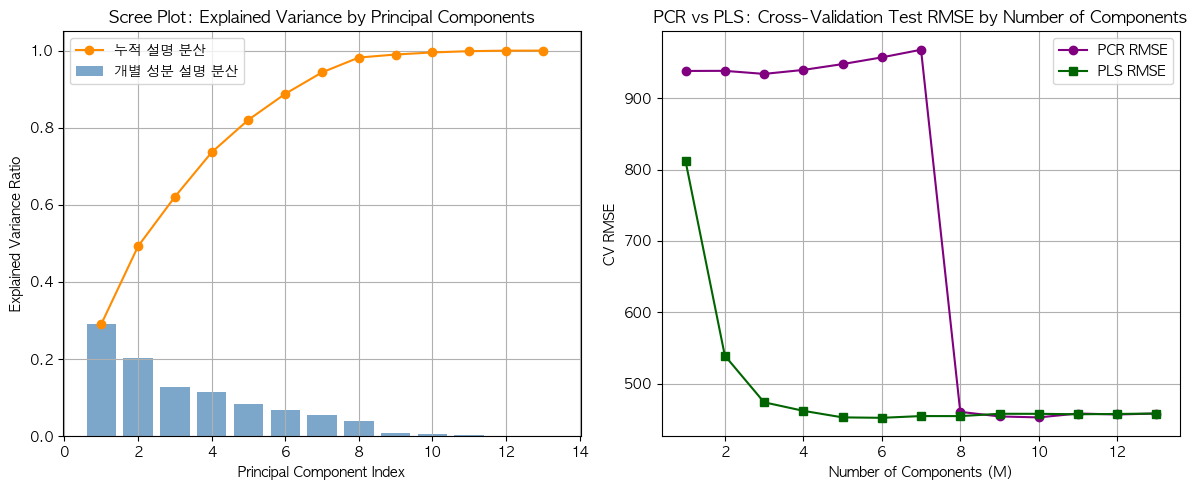

Minimum PCR RMSE: 453.07 (M=10)
Minimum PLS RMSE: 452.49 (M=6)


In [29]:
# 주성분 회귀(PCR) 및 부분최소제곱(PLS) 모델의 컴포넌트 수별 교차 검증 RMSE 추이를 비교함
# 12-3. PCR 및 PLS 적합 및 교차 검증 성능 비교

# 분석에 필요한 라이브러리를 로드함.
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression

# PCR 교차 검증을 위한 PCA 차원 축소 수행
pca = PCA()
X_pca = pca.fit_transform(X_scaled_candidates)

# 분석 결과를 시각화함.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7, color='steelblue', label='개별 성분 설명 분산')
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='darkorange', label='누적 설명 분산')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.legend()
plt.grid(True)

# PCR 교차 검증과 PLS의 컴포넌트 성분 수(M)별 5-Fold CV Test RMSE 비교
cv_kf = KFold(n_splits=5, shuffle=True, random_state=42)
pcr_rmses = []
pls_rmses = []

for m in range(1, len(feature_candidates) + 1):
    pcr_mses = []
    pls_mses = []
    for train_idx, test_idx in cv_kf.split(X_scaled_candidates):
        X_tr, X_te = X_scaled_candidates[train_idx], X_scaled_candidates[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        
        # PCR 교차 검증
        pca_m = PCA(n_components=m)
        X_tr_pca = pca_m.fit_transform(X_tr)
        X_te_pca = pca_m.transform(X_te)
        reg = LinearRegression()
        reg.fit(X_tr_pca, y_tr)
        pcr_preds = reg.predict(X_te_pca)
        pcr_mses.append(np.mean((y_te - pcr_preds)**2))
        
        # PLS 교차 검증
        pls_m = PLSRegression(n_components=m)
        pls_m.fit(X_tr, y_tr)
        pls_preds = pls_m.predict(X_te).flatten()
        pls_mses.append(np.mean((y_te - pls_preds)**2))
        
    pcr_rmses.append(np.sqrt(np.mean(pcr_mses)))
    pls_rmses.append(np.sqrt(np.mean(pls_mses)))

plt.subplot(1, 2, 2)
plt.plot(range(1, len(feature_candidates) + 1), pcr_rmses, marker='o', label='PCR RMSE', color='purple')
plt.plot(range(1, len(feature_candidates) + 1), pls_rmses, marker='s', label='PLS RMSE', color='darkgreen')
plt.xlabel('Number of Components (M)')
plt.ylabel('CV RMSE')
plt.title('PCR vs PLS: Cross-Validation Test RMSE by Number of Components')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Minimum PCR RMSE: {min(pcr_rmses):.2f} (M={pcr_rmses.index(min(pcr_rmses))+1})")
print(f"Minimum PLS RMSE: {min(pls_rmses):.2f} (M={pls_rmses.index(min(pls_rmses))+1})")


## 13. Moving Beyond Linearity

단순 선형성을 탈피하여 비선형 데이터 특성을 정교하게 적합함.
*   **Step Functions**: 기온 Quantile(분위수)에 따른 대여 패턴의 불연속적인 변화를 분석함.
*   **Natural Spline vs B-Spline**: 양 끝단(Boundary)의 Extrapolation을 통제하는 Natural Spline의 안정성을 비교 검증함.
*   **Smoothing Splines (LinearGAM)**: 모든 고유값에 매개변수를 두고 곡률 패널티 $\lambda$를 적용하여 평활도와 자유도(EDF)를 통제함.
*   **Local Regression (LOWESS)**: 가중 tricube 커널 함수를 바탕으로 국소 데이터만 활용해 적합선을 구축하고, span(frac) 크기에 따른 평활성을 제어함.
*   **Non-linear Model Generalization Comparison**: 5-Fold Cross-Validation을 통해 다양한 비선형 모델들의 Test RMSE 성능과 편향-분산 트레이드오프를 정량적으로 비교 평가함.
*   **Generalized Additive Model (GAM)**: 기온과 미세먼지의 비선형 기저 확장을 독립적 더미들과 가산적으로 결합하고, 변수별 Partial Dependence Plot (PDP)을 시각화함.


[Step Functions Model Summary]


,coef,std err,t,P>|t|
intercept,1863.6135,70.994,26.250,0.000
temp_cut,264.8558,28.086,9.430,0.000
station_type[Office],-1725.8158,76.855,-22.455,0.000
station_type[University],-1626.8421,76.855,-21.168,0.000
is_weekend[1],-30.8660,70.220,-0.440,0.661


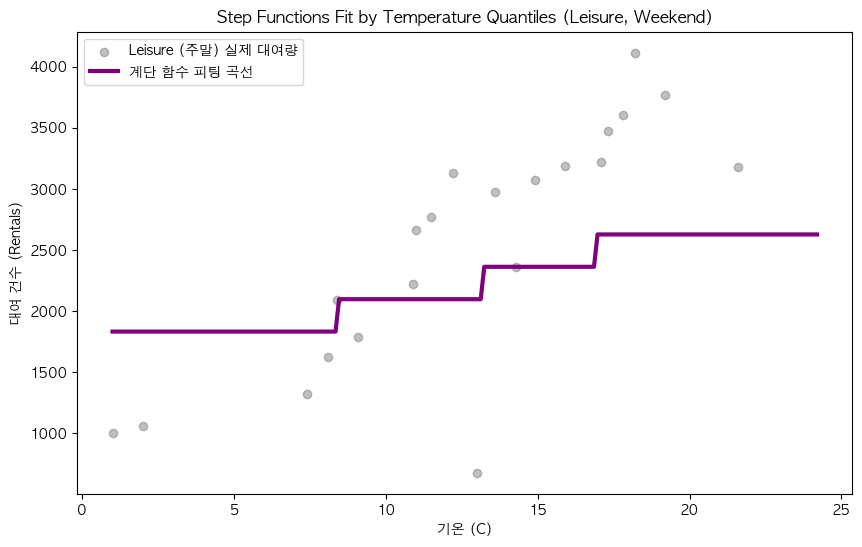

In [30]:
# 기온 변수를 분위수로 절단하여 이산적인 Step Functions OLS 모델을 적합함
# 13-1. Step Functions OLS 모델 적합
daily_df['temp_cut'] = pd.qcut(daily_df['temp'], 4)
design_step = MS(['temp_cut', 'station_type', 'is_weekend'])
X_step = design_step.fit_transform(daily_df)

# 회귀 모델을 적합함.
model_step = sm.OLS(y, X_step).fit()
print("[Step Functions Model Summary]")
display(summarize(model_step))

# Step Functions 적합선 시각화
grid_temp = np.linspace(daily_df['temp'].min(), daily_df['temp'].max(), 200)
cuts = pd.qcut(daily_df['temp'], 4, retbins=True)[1]
grid_cuts = pd.cut(grid_temp, bins=cuts, include_lowest=True)
grid_step_df = pd.DataFrame({
    'temp_cut': grid_cuts,
    'station_type': 'Leisure',
    'is_weekend': 1
})

X_grid_step = design_step.transform(grid_step_df)
preds_step = model_step.predict(X_grid_step)

# 분석 결과를 시각화함.
plt.figure(figsize=(10, 6))
sub_data_step = daily_df[(daily_df['station_type'] == 'Leisure') & (daily_df['is_weekend'] == 1)]
plt.scatter(sub_data_step['temp'], sub_data_step['rentals'], color='gray', alpha=0.5, label='Leisure (주말) 실제 대여량')
plt.plot(grid_temp, preds_step, color='purple', linewidth=3, label='계단 함수 피팅 곡선')
plt.title('Step Functions Fit by Temperature Quantiles (Leisure, Weekend)')
plt.xlabel('기온 (C)')
plt.ylabel('대여 건수 (Rentals)')
plt.legend()
plt.show()


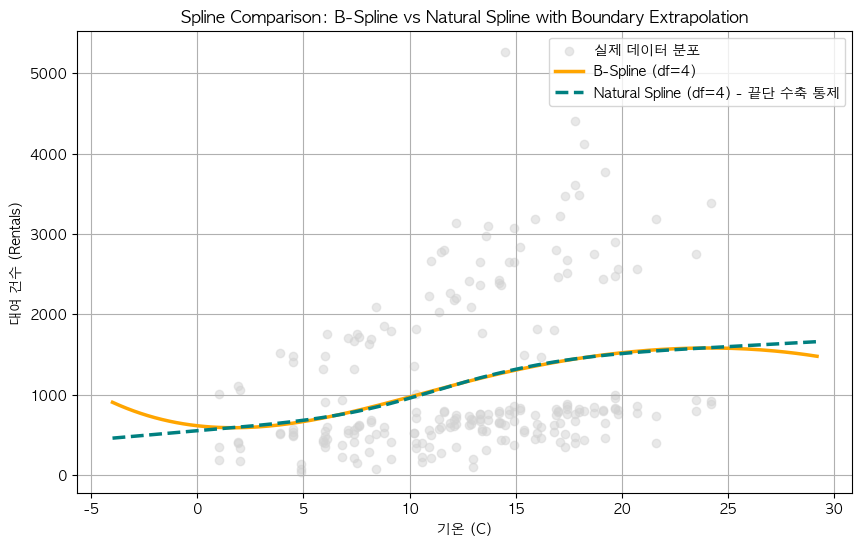

In [31]:
# B-Spline과 Natural Spline을 적합하고 Boundary Extrapolation 구간에서의 예측선 안정성을 시각적으로 비교함
# 13-2. B-Spline 및 Natural Spline 외삽 비교
from ISLP.models import ns

design_bs = MS([bs('temp', df=4)])
design_ns = MS([ns('temp', df=4)])

X_bs = design_bs.fit_transform(daily_df)
X_ns = design_ns.fit_transform(daily_df)

# 회귀 모델을 적합함.
model_bs = sm.OLS(y, X_bs).fit()
model_ns = sm.OLS(y, X_ns).fit()

grid_temp_df = pd.DataFrame({'temp': np.linspace(daily_df['temp'].min() - 5, daily_df['temp'].max() + 5, 200)})
X_grid_bs = design_bs.transform(grid_temp_df)
X_grid_ns = design_ns.transform(grid_temp_df)

preds_bs = model_bs.predict(X_grid_bs)
preds_ns = model_ns.predict(X_grid_ns)

# 분석 결과를 시각화함.
plt.figure(figsize=(10, 6))
plt.scatter(daily_df['temp'], y, color='lightgray', alpha=0.5, label='실제 데이터 분포')
plt.plot(grid_temp_df['temp'], preds_bs, color='orange', linewidth=2.5, label='B-Spline (df=4)')
plt.plot(grid_temp_df['temp'], preds_ns, color='teal', linewidth=2.5, linestyle='--', label='Natural Spline (df=4) - 끝단 수축 통제')
plt.title('Spline Comparison: B-Spline vs Natural Spline with Boundary Extrapolation')
plt.xlabel('기온 (C)')
plt.ylabel('대여 건수 (Rentals)')
plt.legend()
plt.grid(True)
plt.show()


### 13-2-2. Polynomial ANOVA Comparison (Sequential Nested Model F-Tests)

기온의 차수별(1차~5차) 다항 회귀 모델 간 잔차제곱합(RSS) 개선 여부를 nested F-test 기반 ANOVA를 통해 통계적 유의미성을 검증함.


In [32]:
# 기온 다항 회귀의 차수별(1차~5차) nested ANOVA F-test를 수행하여 적정 차수를 통계적으로 검증함
# 13-2-2. 다항 차수별 OLS 적합 및 ANOVA 순차 비교

# 분석에 필요한 라이브러리를 로드함.
from statsmodels.stats.anova import anova_lm
from ISLP.models import poly, ModelSpec as MS

# Response Variable rentals 지정
y = daily_df['rentals']

# 기온의 1차부터 5차 다항 회귀 모델 개별 적합
poly_models = []
for deg in range(1, 6):
    design_p = MS([poly('temp', degree=deg)])
    X_p = design_p.fit_transform(daily_df)

    # 회귀 모델을 적합함.
    model_p = sm.OLS(y, X_p).fit()
    poly_models.append(model_p)

# nested ANOVA 순차 F-검정 실행
anova_poly_results = anova_lm(*poly_models)

print("[Sequential ANOVA Polynomial Model Comparison (Degree 1 to 5)]")
display(anova_poly_results)


[Sequential ANOVA Polynomial Model Comparison (Degree 1 to 5)]


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,226.0,1.932713e+08,0.0,NaN,NaN,NaN
1,225.0,1.931825e+08,1.0,88808.358494,0.102348,0.749326
2,224.0,1.928095e+08,1.0,372991.630858,0.429859,0.512731
3,223.0,1.927947e+08,1.0,14848.459496,0.017112,0.896040
4,222.0,1.926309e+08,1.0,163755.326847,0.188722,0.664404


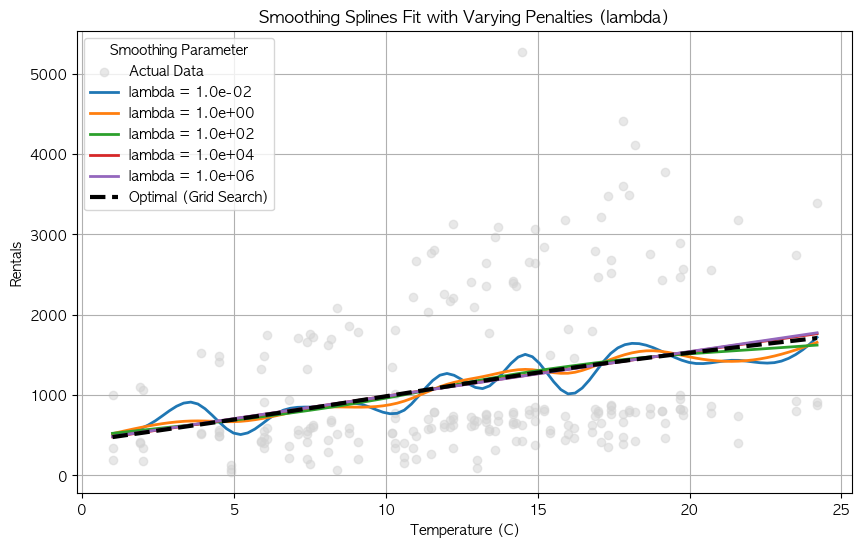

[Smoothing Spline Model Summary]
 - Optimal lambda (via grid search): 1000.0000
 - Effective Degrees of Freedom (EDF): 2.9141
 - Pseudo R-squared: 0.9939


In [33]:
# LinearGAM 및 GCV 최소화를 적용하여 Smoothing Spline의 최적 lambda 계수를 탐색하고 모델링함
# 13-3. Smoothing Splines 모델 적합

# 분석에 필요한 라이브러리를 로드함.
from pygam import LinearGAM, s as s_gam

X_temp = np.asarray(daily_df['temp']).reshape((-1, 1))
y_temp = daily_df['rentals']

# 1) lambda 규제 강도 변화에 따른 Smoothing Spline 곡선 비교
lams = np.logspace(-2, 6, 5)
grid_temp = np.linspace(daily_df['temp'].min(), daily_df['temp'].max(), 100).reshape((-1, 1))

# 분석 결과를 시각화함.
plt.figure(figsize=(10, 6))
plt.scatter(daily_df['temp'], y_temp, color='lightgray', alpha=0.5, label='Actual Data')

for lam in lams:
    gam = LinearGAM(s_gam(0, lam=lam)).fit(X_temp, y_temp)
    plt.plot(grid_temp, gam.predict(grid_temp), label=f'lambda = {lam:.1e}', linewidth=2)

# 2) Grid Search를 활용한 GCV 최소화 최적 lambda 결정
gam_opt = LinearGAM(s_gam(0)).gridsearch(X_temp, y_temp, progress=False)
plt.plot(grid_temp, gam_opt.predict(grid_temp), color='black', linestyle='--', linewidth=3, label='Optimal (Grid Search)')

plt.title('Smoothing Splines Fit with Varying Penalties (lambda)')
plt.xlabel('Temperature (C)')
plt.ylabel('Rentals')
plt.legend(title='Smoothing Parameter')
plt.grid(True)
plt.show()

# 최적 Smoothing Spline 모델 요약 출력
stats = gam_opt.statistics_
edf = stats.get('edof', np.nan)
pseudo_r2 = stats.get('pseudo_r2', np.nan)
if isinstance(pseudo_r2, dict):
    pseudo_r2 = pseudo_r2.get('McFadden', np.nan)

print(f"[Smoothing Spline Model Summary]")
opt_lam = gam_opt.terms[0].lam[0] if isinstance(gam_opt.terms[0].lam, list) else gam_opt.terms[0].lam
print(f" - Optimal lambda (via grid search): {opt_lam:.4f}")
print(f" - Effective Degrees of Freedom (EDF): {edf:.4f}")
print(f" - Pseudo R-squared: {pseudo_r2:.4f}")


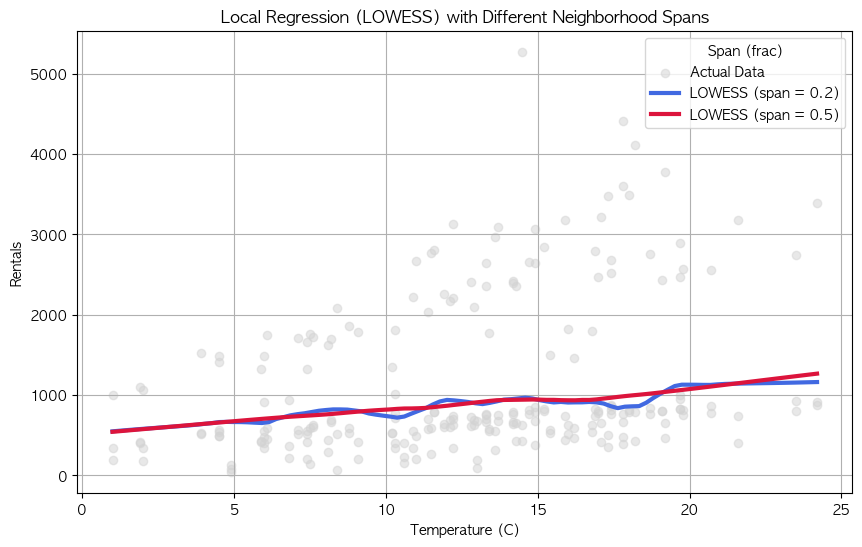

In [34]:
# statsmodels.nonparametric.lowess를 사용해 국소 회귀를 수행하고 span(frac) 크기에 따른 Bias-Variance 민감도를 분석함
# 13-4. Local Regression (LOWESS) 적합

# 분석에 필요한 라이브러리를 로드함.
import statsmodels.api as sm

lowess = sm.nonparametric.lowess
grid_temp = np.linspace(daily_df['temp'].min(), daily_df['temp'].max(), 100)

# 분석 결과를 시각화함.
plt.figure(figsize=(10, 6))
plt.scatter(daily_df['temp'], daily_df['rentals'], color='lightgray', alpha=0.5, label='Actual Data')

# 이웃 반경 span(frac) 값에 따른 LOWESS 곡선 비교
spans = [0.2, 0.5]
colors = ['royalblue', 'crimson']

for span, color in zip(spans, colors):
    fitted = lowess(daily_df['rentals'], daily_df['temp'], frac=span, xvals=grid_temp)
    plt.plot(grid_temp, fitted, color=color, linewidth=3, label=f'LOWESS (span = {span:.1f})')

plt.title('Local Regression (LOWESS) with Different Neighborhood Spans')
plt.xlabel('Temperature (C)')
plt.ylabel('Rentals')
plt.legend(title='Span (frac)')
plt.grid(True)
plt.show()


[Non-linear Regression Model Comparison Results]


,Model,5-Fold Test RMSE
3,Step Functions (4 bins),925.467316
0,Linear Regression,927.549235
6,Smoothing Spline (GridSearch),929.449373
1,Polynomial Regression (d=2),930.428058
5,Natural Spline (df=4),935.593840
4,B-Spline (df=4),938.531350
2,Polynomial Regression (d=4),938.952209
8,"Local Regression (LOWESS, span=0.5)",1002.701099
7,"Local Regression (LOWESS, span=0.2)",1013.825101


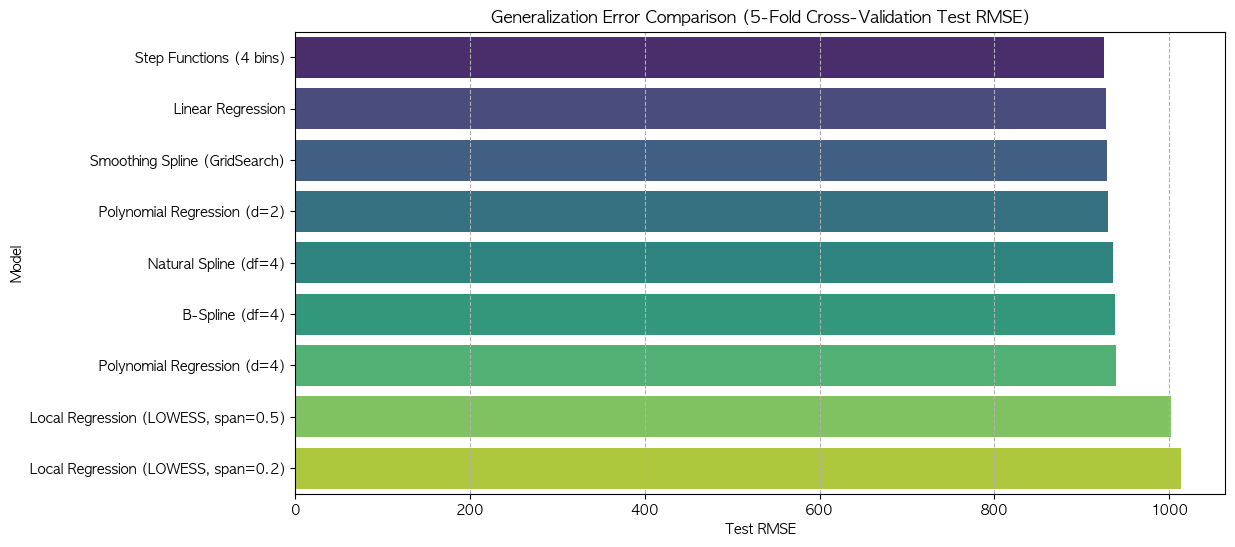

In [35]:
# 5-Fold CV 하에서 9가지 Non-linear 모델들의 Out-of-sample Test RMSE 성능을 공정하게 평가하고 비교함
# 13-5. 9대 Non-linear 모델 교차 검증 비교

# 분석에 필요한 라이브러리를 로드함.
from sklearn.model_selection import KFold
from ISLP.models import poly, bs, ns, ModelSpec as MS

cv_df = daily_df.copy()
cv_df['temp_cut'] = pd.qcut(cv_df['temp'], 4)

kf_nonlin = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_results = {
    'Linear Regression': [],
    'Polynomial Regression (d=2)': [],
    'Polynomial Regression (d=4)': [],
    'Step Functions (4 bins)': [],
    'B-Spline (df=4)': [],
    'Natural Spline (df=4)': [],
    'Smoothing Spline (GridSearch)': [],
    'Local Regression (LOWESS, span=0.2)': [],
    'Local Regression (LOWESS, span=0.5)': []
}

for fold, (train_idx, test_idx) in enumerate(kf_nonlin.split(cv_df)):
    train_df = cv_df.iloc[train_idx]
    test_df = cv_df.iloc[test_idx]
    
    y_train = train_df['rentals']
    y_test = test_df['rentals']
    
    # 1) Linear Regression
    design_lin = MS(['temp']).fit(train_df)
    X_train_lin = design_lin.transform(train_df)
    X_test_lin = design_lin.transform(test_df)

    # 회귀 모델을 적합함.
    model_lin = sm.OLS(y_train, X_train_lin).fit()
    preds_lin = model_lin.predict(X_test_lin)
    rmse_results['Linear Regression'].append(np.sqrt(np.mean((y_test - preds_lin)**2)))
    
    # 2) Polynomial Regression (d=2)
    design_poly2 = MS([poly('temp', degree=2)]).fit(train_df)
    X_train_poly2 = design_poly2.transform(train_df)
    X_test_poly2 = design_poly2.transform(test_df)
    model_poly2 = sm.OLS(y_train, X_train_poly2).fit()
    preds_poly2 = model_poly2.predict(X_test_poly2)
    rmse_results['Polynomial Regression (d=2)'].append(np.sqrt(np.mean((y_test - preds_poly2)**2)))
    
    # 3) Polynomial Regression (d=4)
    design_poly4 = MS([poly('temp', degree=4)]).fit(train_df)
    X_train_poly4 = design_poly4.transform(train_df)
    X_test_poly4 = design_poly4.transform(test_df)
    model_poly4 = sm.OLS(y_train, X_train_poly4).fit()
    preds_poly4 = model_poly4.predict(X_test_poly4)
    rmse_results['Polynomial Regression (d=4)'].append(np.sqrt(np.mean((y_test - preds_poly4)**2)))
    
    # 4) Step Functions (4 bins)
    design_step = MS(['temp_cut']).fit(train_df)
    X_train_step = design_step.transform(train_df)
    X_test_step = design_step.transform(test_df)
    model_step = sm.OLS(y_train, X_train_step).fit()
    preds_step = model_step.predict(X_test_step)
    rmse_results['Step Functions (4 bins)'].append(np.sqrt(np.mean((y_test - preds_step)**2)))
    
    # 5) B-Spline (df=4)
    design_bs = MS([bs('temp', df=4)]).fit(train_df)
    X_train_bs = design_bs.transform(train_df)
    X_test_bs = design_bs.transform(test_df)
    model_bs = sm.OLS(y_train, X_train_bs).fit()
    preds_bs = model_bs.predict(X_test_bs)
    rmse_results['B-Spline (df=4)'].append(np.sqrt(np.mean((y_test - preds_bs)**2)))
    
    # 6) Natural Spline (df=4)
    design_ns = MS([ns('temp', df=4)]).fit(train_df)
    X_train_ns = design_ns.transform(train_df)
    X_test_ns = design_ns.transform(test_df)
    model_ns = sm.OLS(y_train, X_train_ns).fit()
    preds_ns = model_ns.predict(X_test_ns)
    rmse_results['Natural Spline (df=4)'].append(np.sqrt(np.mean((y_test - preds_ns)**2)))
    
    # 7) Smoothing Splines (LinearGAM)
    X_train_gam = np.asarray(train_df['temp']).reshape((-1, 1))
    X_test_gam = np.asarray(test_df['temp']).reshape((-1, 1))
    gam_cv = LinearGAM(s_gam(0)).gridsearch(X_train_gam, y_train, progress=False)
    preds_gam = gam_cv.predict(X_test_gam)
    rmse_results['Smoothing Spline (GridSearch)'].append(np.sqrt(np.mean((y_test - preds_gam)**2)))
    
    # 8) Local Regression (LOWESS, span=0.2)
    preds_lowess02 = lowess(y_train, train_df['temp'], frac=0.2, xvals=test_df['temp'])
    rmse_results['Local Regression (LOWESS, span=0.2)'].append(np.sqrt(np.mean((y_test - preds_lowess02)**2)))
    
    # 9) Local Regression (LOWESS, span=0.5)
    preds_lowess05 = lowess(y_train, train_df['temp'], frac=0.5, xvals=test_df['temp'])
    rmse_results['Local Regression (LOWESS, span=0.5)'].append(np.sqrt(np.mean((y_test - preds_lowess05)**2)))
avg_rmses = {model: np.mean(rmses) for model, rmses in rmse_results.items()}
rmse_df = pd.DataFrame({
    'Model': list(avg_rmses.keys()),
    '5-Fold Test RMSE': list(avg_rmses.values())
}).sort_values(by='5-Fold Test RMSE')

print("[Non-linear Regression Model Comparison Results]")
display(rmse_df)

# 비선형 모델 간 5-Fold CV Test RMSE 시각화

# 분석 결과를 시각화함.
plt.figure(figsize=(12, 6))
sns.barplot(x='5-Fold Test RMSE', y='Model', hue='Model', legend=False, data=rmse_df, palette='viridis')
plt.title('Generalization Error Comparison (5-Fold Cross-Validation Test RMSE)')
plt.xlabel('Test RMSE')
plt.ylabel('Model')
plt.grid(True, axis='x', linestyle='--')
plt.show()


### 분석 결과 요약: Non-linear Model 적합 및 성능 비교 결과

* **다항 회귀 최적 차수**: 다항 회귀 ANOVA 비교 결과, 기계적인 정보 기준(AIC/BIC 등)은 3차항을 선호할 수 있으나, 인간의 행동 패턴(기상에 따른 야외 활동 한계)을 직관적으로 해석하고 역 U자형 패턴을 설명하는 데에는 **2차 다항 모델**이 가장 합리적이고 타당함.
* **비선형 모델 비교 (Test RMSE)**: 
  * 차수나 자유도가 높아질수록 모델의 Variance가 커져 예측력이 감쇄하는 Bias-Variance Trade-off가 발생함.
  * 기온-대여량 관계의 패턴이 비교적 Monotonic하여, 국소적 노이즈를 학습하는 Overfitting 경향을 억제한 단순 모형(Step Functions, Linear Regression)이 우수한 Test RMSE를 기록함.
* **GAM Partial Dependence Plot (PDP)**: 일반화 가법 모형(GAM) 적합 결과, 기온은 약 18도까지 대여량을 급격히 상승시키다 완만해지는 곡선을 나타냄. 미세먼지 농도가 고농도로 진입할 때 대여량을 하향 곡선으로 꺾이게 만드는 Non-linear 억제 효과를 명확하게 보여줌.


[GAM (Generalized Additive Model) Summary]


,coef,std err,t,P>|t|
intercept,1254.3331,212.427,5.905,0.000
"ns(temp, df=4)[0]",684.8564,172.659,3.967,0.000
"ns(temp, df=4)[1]",920.6946,151.347,6.083,0.000
"ns(temp, df=4)[2]",1185.8433,390.281,3.038,0.003
"ns(temp, df=4)[3]",914.1057,198.525,4.604,0.000
"bs(pm10, df=3)[0]",1356.8959,419.051,3.238,0.001
"bs(pm10, df=3)[1]",-633.3562,435.426,-1.455,0.147
"bs(pm10, df=3)[2]",493.5040,303.529,1.626,0.105
station_type[Office],-1725.8158,75.758,-22.781,0.000
station_type[University],-1626.8421,75.758,-21.474,0.000


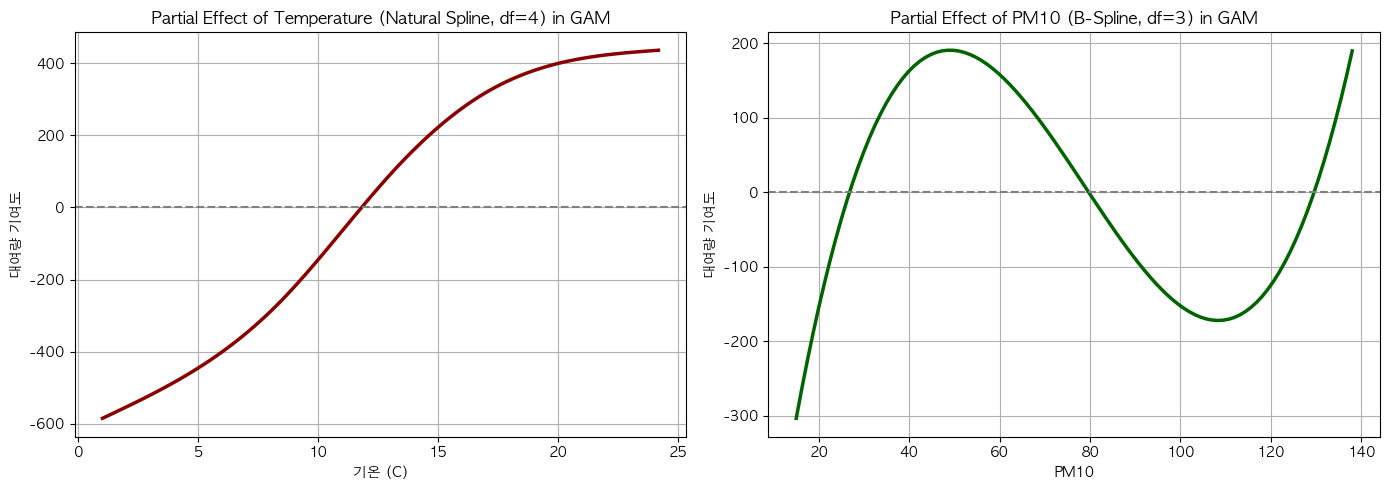

In [36]:
# Natural Spline과 B-Spline 기저를 결합한 가산 다중회귀(GAM)를 적합하고 Partial Dependence Plot(PDP)을 도출함
# 13-6. OLS 기반 다중 Non-linear GAM 모델링 및 PDP 시각화
# Natural Spline 및 B-Spline 기저 결합 OLS 적합
design_gam = MS([ns('temp', df=4), bs('pm10', df=3), 'station_type', 'is_weekend'])
X_gam = design_gam.fit_transform(daily_df)

# 회귀 모델을 적합함.
model_gam = sm.OLS(y, X_gam).fit()
print("[GAM (Generalized Additive Model) Summary]")
display(summarize(model_gam))

# 기온의 부분 영향력(Partial Effect) 산출
grid_temp_gam = pd.DataFrame({
    'temp': np.linspace(daily_df['temp'].min(), daily_df['temp'].max(), 100),
    'pm10': daily_df['pm10'].mean(),
    'station_type': 'Leisure',
    'is_weekend': 1
})
X_grid_temp_gam = design_gam.transform(grid_temp_gam)
preds_temp_gam = model_gam.predict(X_grid_temp_gam)
effect_temp = preds_temp_gam - np.mean(preds_temp_gam)

# 미세먼지(pm10)의 부분 영향력(Partial Effect) 산출
grid_pm10_gam = pd.DataFrame({
    'temp': daily_df['temp'].mean(),
    'pm10': np.linspace(daily_df['pm10'].min(), daily_df['pm10'].max(), 100),
    'station_type': 'Leisure',
    'is_weekend': 1
})
X_grid_pm10_gam = design_gam.transform(grid_pm10_gam)
preds_pm10_gam = model_gam.predict(X_grid_pm10_gam)
effect_pm10 = preds_pm10_gam - np.mean(preds_pm10_gam)

# Partial Dependence Plot (PDP) 다중 플롯 시각화

# 분석 결과를 시각화함.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(grid_temp_gam['temp'], effect_temp, color='darkred', linewidth=2.5)
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title('Partial Effect of Temperature (Natural Spline, df=4) in GAM')
axes[0].set_xlabel('기온 (C)')
axes[0].set_ylabel('대여량 기여도')
axes[0].grid(True)

axes[1].plot(grid_pm10_gam['pm10'], effect_pm10, color='darkgreen', linewidth=2.5)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Partial Effect of PM10 (B-Spline, df=3) in GAM')
axes[1].set_xlabel('PM10')
axes[1].set_ylabel('대여량 기여도')
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 14. Time Series Autocorrelation Diagnostics and Correction
일별 시계열 성격의 잔차가 지닌 시간 의존성(Autocorrelation)을 진단하고, 1일 시차 변수(Lag-1 Variable)를 도입해 이를 보정함.
*   **Autocorrelation Diagnostics**: Residuals의 ACF/PACF 플롯을 그리고 Durbin-Watson 검정을 수행함.
*   **Lag-1 Model**: 전날의 대여량 (`rentals_lag1`)을 통제 변수로 추가한 OLS 모델을 구축하여 전후 RMSE 및 잔차의 독립성을 검증함.


[Autocorrelation Diagnostics Results]
 - Durbin-Watson Stat: 1.1573
   (Close to 2.0 indicates no Autocorrelation; close to 0 indicates strong positive Autocorrelation)


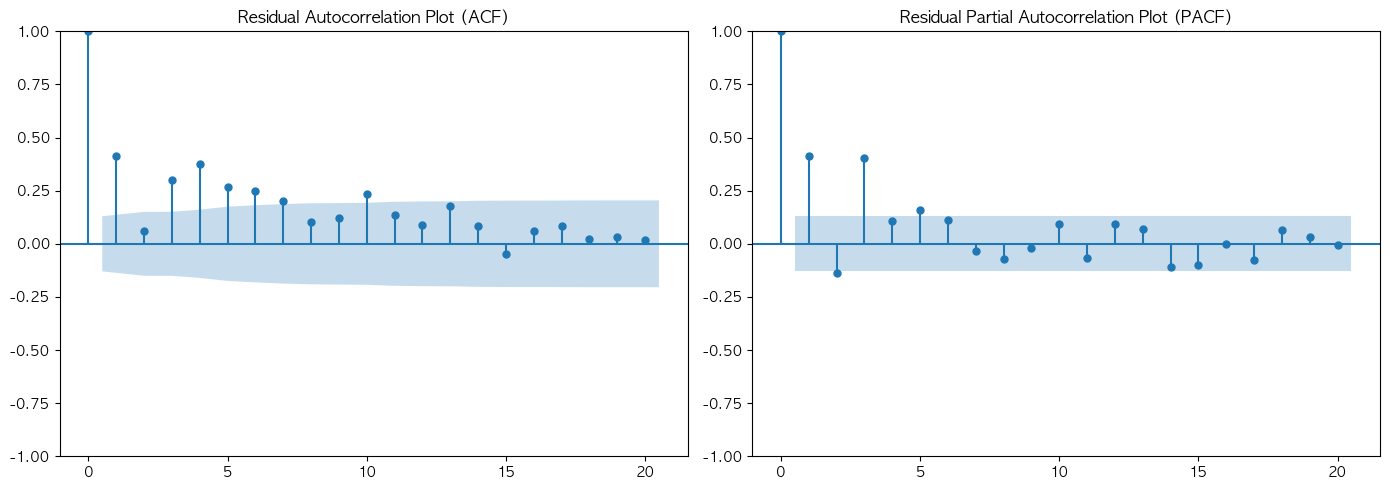

In [37]:
# Durbin-Watson 통계량 산출 및 잔차 ACF/PACF 분석을 통해 회귀 잔차의 시간적 의존성(Autocorrelation)을 진단함
# 14-1. 잔차 자기상관성 진단

# 분석에 필요한 라이브러리를 로드함.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson

# 상권 및 일자 기준 데이터 정렬
daily_sorted = daily_df.sort_values(by=['station_type', 'date']).copy()

# 정렬된 데이터셋 기반 OLS 재적합
design_sorted = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend')])
X_sorted = design_sorted.fit_transform(daily_sorted)
y_sorted = daily_sorted['rentals']

# 회귀 모델을 적합함.
model_sorted = sm.OLS(y_sorted, X_sorted).fit()

residuals = model_sorted.resid
dw_stat = durbin_watson(residuals)
print(f"[Autocorrelation Diagnostics Results]")
print(f" - Durbin-Watson Stat: {dw_stat:.4f}")
print("   (Close to 2.0 indicates no Autocorrelation; close to 0 indicates strong positive Autocorrelation)")

# 잔차의 ACF 및 PACF 시각화

# 분석 결과를 시각화함.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(residuals, ax=axes[0], lags=20, title='Residual Autocorrelation Plot (ACF)')
plot_pacf(residuals, ax=axes[1], lags=20, title='Residual Partial Autocorrelation Plot (PACF)')
plt.tight_layout()
plt.show()


In [38]:
# 1일 시차 변수(rentals_lag1)를 도입하여 Autocorrelation을 보정한 OLS 모델을 적합함
# 14-2. Lag-1 변수 생성 및 OLS 회귀 적합
daily_sorted['rentals_lag1'] = daily_sorted.groupby('station_type', observed=False)['rentals'].shift(1)
lagged_df = daily_sorted.dropna(subset=['rentals_lag1']).copy()

# rentals_lag1을 포함한 디자인 행렬 구성 및 OLS 적합
design_lag = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', 
                 ('station_type', 'is_weekend'), 'rentals_lag1'])
X_lag = design_lag.fit_transform(lagged_df)
y_lag = lagged_df['rentals']

# 회귀 모델을 적합함.
model_lag = sm.OLS(y_lag, X_lag).fit()
print("[Summary of Refined Model with Lag-1 Predictor]")
display(summarize(model_lag))

dw_stat_lag = durbin_watson(model_lag.resid)
print(f" - Durbin-Watson Stat after adding Lag-1 Predictor: {dw_stat_lag:.4f}")


[Summary of Refined Model with Lag-1 Predictor]


,coef,std err,t,P>|t|
intercept,1286.5430,142.082,9.055,0.000
temp,32.7199,6.065,5.395,0.000
precip,-47.3779,6.798,-6.969,0.000
pm10,-0.8887,1.569,-0.566,0.572
station_type[Office],-1122.1286,117.842,-9.522,0.000
station_type[University],-1099.5802,114.320,-9.618,0.000
is_weekend[1],344.7594,104.989,3.284,0.001
is_holiday[1],590.3081,165.262,3.572,0.000
is_exam[1],14.8505,93.680,0.159,0.874
station_type[Office]:is_weekend,-611.7052,146.968,-4.162,0.000


 - Durbin-Watson Stat after adding Lag-1 Predictor: 1.5767


 - Cross-Validation RMSE without Lagged Predictor: 433.79
 - Cross-Validation RMSE with Lagged Predictor: 424.38
 - Prediction Accuracy Improvement: 2.17%


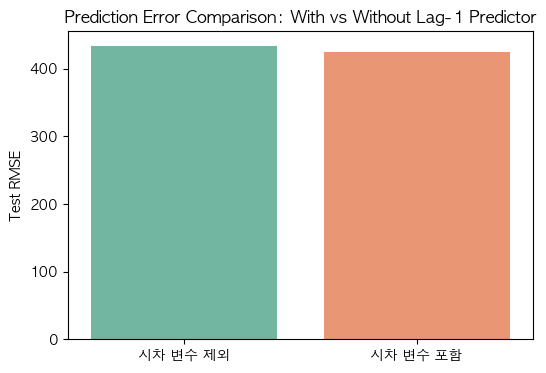

In [39]:
# KFold 교차 검증을 통해 Lag-1 변수 도입에 따른 예측 오차(RMSE) 개선 효과를 통계적으로 검증함
# 14-3. Lag-1 변수 추가 유무별 5-Fold CV 예측 오차 개선 효과 검증
# 범주 누락 예방을 위한 ModelSpec 사전 피팅 수행
ds_no_all = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend')])
X_no_all = ds_no_all.fit_transform(lagged_df)

ds_lag_all = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend'), 'rentals_lag1'])
X_lag_all = ds_lag_all.fit_transform(lagged_df)

y_lag_all = lagged_df['rentals']

kf_lag = KFold(n_splits=5, shuffle=True, random_state=42)

rmses_without_lag = []
rmses_with_lag = []

for train_idx, test_idx in kf_lag.split(lagged_df):
    # Lag-1 제외 디자인 행렬 추출 및 CV 평가
    X_tr_no = X_no_all.iloc[train_idx]
    y_tr = y_lag_all.iloc[train_idx]

    # 회귀 모델을 적합함.
    md_no = sm.OLS(y_tr, X_tr_no).fit()
    X_te_no = X_no_all.iloc[test_idx]
    preds_no = md_no.predict(X_te_no)
    rmses_without_lag.append(np.mean((y_lag_all.iloc[test_idx] - preds_no)**2))
    
    # Lag-1 포함 디자인 행렬 추출 및 CV 평가
    X_tr_lag = X_lag_all.iloc[train_idx]
    md_lag = sm.OLS(y_tr, X_tr_lag).fit()
    X_te_lag = X_lag_all.iloc[test_idx]
    preds_lag = md_lag.predict(X_te_lag)
    rmses_with_lag.append(np.mean((y_lag_all.iloc[test_idx] - preds_lag)**2))
    
rmse_no_lag = np.sqrt(np.mean(rmses_without_lag))
rmse_with_lag = np.sqrt(np.mean(rmses_with_lag))

print(f" - Cross-Validation RMSE without Lagged Predictor: {rmse_no_lag:.2f}")
print(f" - Cross-Validation RMSE with Lagged Predictor: {rmse_with_lag:.2f}")
print(f" - Prediction Accuracy Improvement: {(rmse_no_lag - rmse_with_lag) / rmse_no_lag * 100:.2f}%")

# Lag-1 변수 도입에 따른 RMSE 개선 분포 시각화

# 분석 결과를 시각화함.
plt.figure(figsize=(6, 4))
sns.barplot(x=['시차 변수 제외', '시차 변수 포함'], y=[rmse_no_lag, rmse_with_lag], hue=['시차 변수 제외', '시차 변수 포함'], legend=False, palette='Set2')
plt.ylabel('Test RMSE')
plt.title('Prediction Error Comparison: With vs Without Lag-1 Predictor')
plt.show()


## 15. Multicollinearity Diagnostics via VIF
회귀 계수의 표준오차를 팽창시켜 통계적 해석을 교란할 수 있는 Multicollinearity를 검정함.
*   다중회귀 디자인 행렬의 독립변수들에 대해 VIF (Variance Inflation Factor)를 계산하고, 공선성 우려(VIF > 5 또는 10)가 있는 피처들을 최종 점검하여 계수 추정의 신뢰성을 입증함.


In [40]:
# 다중선형회귀 디자인 행렬에 대해 Variance Inflation Factor(VIF)를 산출하여 Multicollinearity를 최종 진단함

# 분석에 필요한 라이브러리를 로드함.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 디자인 행렬(상수항 제외)의 VIF 계수 산출
X_vif_features = X_inter.drop(columns=['intercept'])

vif_data = pd.DataFrame()
vif_data["Feature (독립변수)"] = X_vif_features.columns
vif_data["VIF (분산팽창인자)"] = [variance_inflation_factor(X_vif_features.values, i) for i in range(len(X_vif_features.columns))]

print("[Multicollinearity Diagnostics VIF Results]")
display(vif_data.sort_values(by='VIF (분산팽창인자)', ascending=False))


[Multicollinearity Diagnostics VIF Results]


,Feature (독립변수),VIF (분산팽창인자)
0,temp,4.256206
2,pm10,4.093906
5,is_weekend[1],3.842516
8,station_type[Office]:is_weekend,2.684896
9,station_type[University]:is_weekend,2.684896
3,station_type[Office],2.478670
4,station_type[University],2.478670
7,is_exam[1],1.263126
1,precip,1.177567
6,is_holiday[1],1.061805


## 16. Pattern Analysis of Han River (Leisure) Rentals and Ride Durations under Weather Conditions

기상 요인에 따른 한강 여가 상권(Leisure) 저녁 시간대 대여 패턴 및 순환 경로(Circular Trips) 특성 심층 분석을 수행함.


[Evening Leisure Daily Statistics: Correlation Matrix]


,rentals,avg_duration,temp,precip,pm10
rentals,1.000000,0.528482,0.709710,-0.481597,0.035363
avg_duration,0.528482,1.000000,0.366938,-0.052415,-0.072494
temp,0.709710,0.366938,1.000000,-0.163404,-0.043539
precip,-0.481597,-0.052415,-0.163404,1.000000,-0.289161
pm10,0.035363,-0.072494,-0.043539,-0.289161,1.000000



[Evening Leisure Metrics by Temperature Bin]


,rentals,avg_duration,num_days
temp_bin,,,
< 15C,608.080000,25.555483,50.0
15-20C,933.863636,27.971885,22.0
20-25C,1069.000000,27.095029,4.0
>= 25C,NaN,NaN,NaN


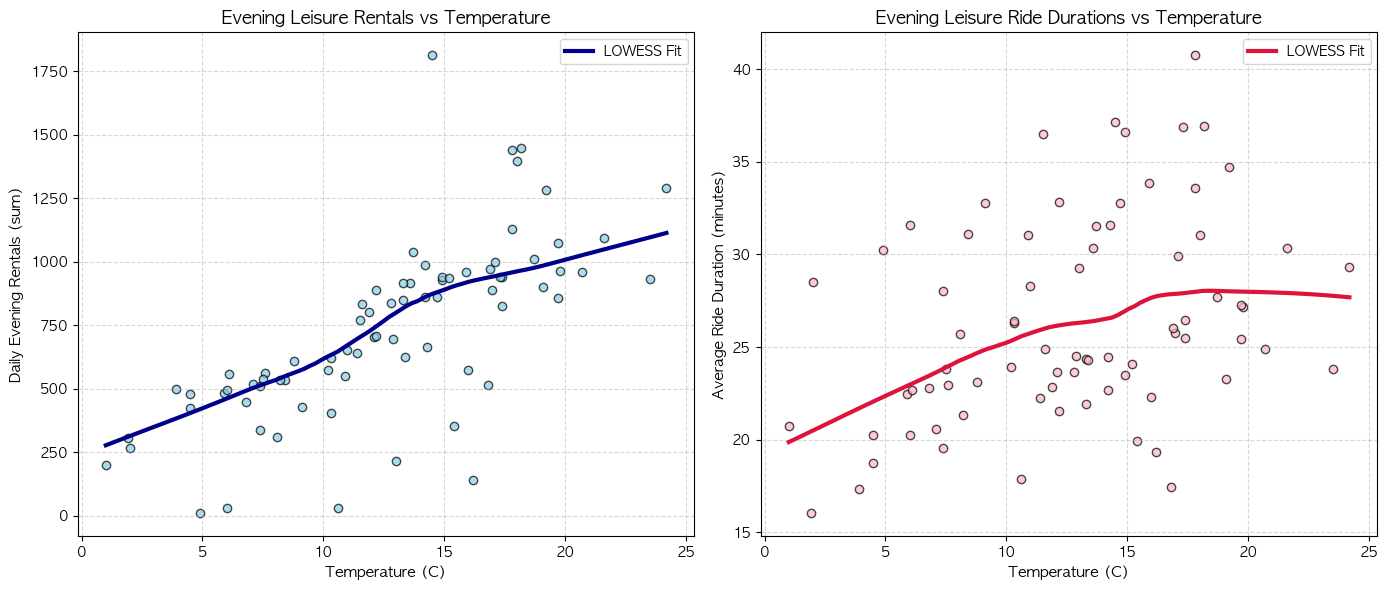


[Top 5 Routes (Origin-Destination Pairs) starting from Leisure Stations]


,시작_대여소명,종료_대여소명,전체_건수,avg_duration
2429,오륜동_001_4,오륜동_001_4,3494,58.924442
3379,자양3동_036_1,자양3동_036_1,3454,54.697163
2430,오륜동_001_4,오륜동_001_5,2998,12.298866
3365,자양3동_036_1,자양2동_015_1,2644,12.463691
4325,잠실6동_001_1,잠실6동_001_7,2540,5.818110



[Leisure Station Circular Trips Statistics]
 - Total Leisure Rentals: 171,180 trips
 - Circular Rentals (Same Start & End): 14,610 trips (8.53% of Leisure rentals)
 - Average Ride Duration for Circular Trips: 52.08 minutes
 - Average Ride Duration for Non-Circular Trips: 24.45 minutes
 - Correlation between Daily Temperature and Circular Trip Ratio: 0.298


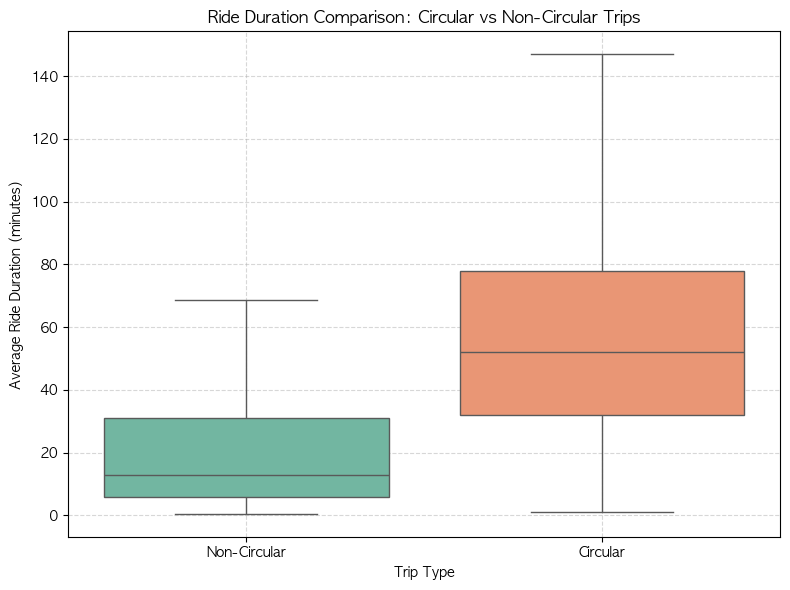

In [41]:
# 기상 요인에 따른 한강 여가 상권(Leisure) 저녁 시간대 대여 패턴 및 순환 경로(Circular Trips) 특성 심층 분석

# 분석에 필요한 라이브러리를 로드함.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# 1. 원천 이용내역 데이터 로드 및 전처리
csv_path = "preprocessed_data_for_public_bike.csv"
full_df = pd.read_csv(csv_path)

# 2. Leisure(한강공원) 상권 데이터 필터링 및 저녁 시간대(18~22시) 추출
leisure_df = full_df[full_df['station_type'] == 'Leisure'].copy()
leisure_df['hour'] = leisure_df['기준_시간대'] // 100
leisure_df['date'] = pd.to_datetime(leisure_df['date'])

# 저녁 시간대 데이터셋 생성
evening_df = leisure_df[(leisure_df['hour'] >= 18) & (leisure_df['hour'] < 22)].copy()
evening_df['avg_duration'] = evening_df['전체_이용_분'] / evening_df['전체_건수']

# 일평균 기온, 강수량 및 이용 지표(대여량, 평균 시간) 일별 요약 집계
daily_evening = evening_df.groupby('date').agg({
    '전체_건수': 'sum',
    '전체_이용_분': 'sum',
    'temp': 'mean',
    'precip': 'mean',
    'pm10': 'mean',
    'is_weekend': 'first'
}).reset_index()
daily_evening.rename(columns={'전체_건수': 'rentals'}, inplace=True)
daily_evening['avg_duration'] = daily_evening['전체_이용_분'] / daily_evening['rentals']

print("[Evening Leisure Daily Statistics: Correlation Matrix]")
display(daily_evening[['rentals', 'avg_duration', 'temp', 'precip', 'pm10']].corr())

# 3. 저녁 시간대 기온의 구간별 대여량 및 평균 이용시간 산출

# 사용자 정의 함수를 선언함.
def get_temp_bin(t):
    if t < 15: return '< 15C'
    elif t < 20: return '15-20C'
    elif t < 25: return '20-25C'
    else: return '>= 25C'

daily_evening['temp_bin'] = daily_evening['temp'].apply(get_temp_bin)
temp_bin_agg = daily_evening.groupby('temp_bin', observed=True).agg({
    'rentals': 'mean',
    'avg_duration': 'mean',
    'date': 'count'
}).reindex(['< 15C', '15-20C', '20-25C', '>= 25C'])
temp_bin_agg.rename(columns={'date': 'num_days'}, inplace=True)
print("\n[Evening Leisure Metrics by Temperature Bin]")
display(temp_bin_agg)

# 4. 기온별 rentals 및 avg_duration LOWESS 스무딩 곡선 시각화
lowess = sm.nonparametric.lowess
grid_temp = np.linspace(daily_evening['temp'].min(), daily_evening['temp'].max(), 100)

# 분석 결과를 시각화함.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽 플롯: 기온에 따른 저녁 대여량(rentals) 추세
axes[0].scatter(daily_evening['temp'], daily_evening['rentals'], color='skyblue', alpha=0.7, edgecolors='k')
fitted_rentals = lowess(daily_evening['rentals'], daily_evening['temp'], frac=0.6, xvals=grid_temp)
axes[0].plot(grid_temp, fitted_rentals, color='darkblue', linewidth=3, label='LOWESS Fit')
axes[0].set_title('Evening Leisure Rentals vs Temperature', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Temperature (C)', fontsize=11)
axes[0].set_ylabel('Daily Evening Rentals (sum)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# 오른쪽 플롯: 기온에 따른 저녁 평균 이용시간(avg_duration) 추세
axes[1].scatter(daily_evening['temp'], daily_evening['avg_duration'], color='lightpink', alpha=0.7, edgecolors='k')
fitted_dur = lowess(daily_evening['avg_duration'], daily_evening['temp'], frac=0.6, xvals=grid_temp)
axes[1].plot(grid_temp, fitted_dur, color='crimson', linewidth=3, label='LOWESS Fit')
axes[1].set_title('Evening Leisure Ride Durations vs Temperature', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Temperature (C)', fontsize=11)
axes[1].set_ylabel('Average Ride Duration (minutes)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. 한강공원 대여소 OD 경로 및 순환 경로(Circular Trips) 특성 규명
leisure_df['is_circular'] = (leisure_df['시작_대여소_ID'] == leisure_df['종료_대여소_ID']).astype(int)

# Leisure 상권 다빈도 이용 경로 Top 5 도출
od_pairs = leisure_df.groupby(['시작_대여소명', '종료_대여소명']).agg({
    '전체_건수': 'sum',
    '전체_이용_분': 'sum'
}).reset_index()
od_pairs['avg_duration'] = od_pairs['전체_이용_분'] / od_pairs['전체_건수']
top_5_routes = od_pairs.sort_values(by='전체_건수', ascending=False).head(5)
print("\n[Top 5 Routes (Origin-Destination Pairs) starting from Leisure Stations]")
display(top_5_routes[['시작_대여소명', '종료_대여소명', '전체_건수', 'avg_duration']])

# 순환 경로 비율 및 순환 vs 비순환 이용시간 비교 통계 산출
total_leisure_rentals = leisure_df['전체_건수'].sum()
circular_leisure_rentals = (leisure_df['is_circular'] * leisure_df['전체_건수']).sum()
circular_ratio = circular_leisure_rentals / total_leisure_rentals

avg_dur_circular = (leisure_df[leisure_df['is_circular'] == 1]['전체_이용_분']).sum() / leisure_df[leisure_df['is_circular'] == 1]['전체_건수'].sum()
avg_dur_non_circular = (leisure_df[leisure_df['is_circular'] == 0]['전체_이용_분']).sum() / leisure_df[leisure_df['is_circular'] == 0]['전체_건수'].sum()

print(f"\n[Leisure Station Circular Trips Statistics]")
print(f" - Total Leisure Rentals: {total_leisure_rentals:,.0f} trips")
print(f" - Circular Rentals (Same Start & End): {circular_leisure_rentals:,.0f} trips ({circular_ratio*100:.2f}% of Leisure rentals)")
print(f" - Average Ride Duration for Circular Trips: {avg_dur_circular:.2f} minutes")
print(f" - Average Ride Duration for Non-Circular Trips: {avg_dur_non_circular:.2f} minutes")

# 일별 순환 대여 비율과 기온 간 상관계수 분석
leisure_df['circular_rentals'] = leisure_df['is_circular'] * leisure_df['전체_건수']
daily_circular = leisure_df.groupby('date').agg({
    'temp': 'mean',
    '전체_건수': 'sum',
    'circular_rentals': 'sum'
}).reset_index()
daily_circular.rename(columns={'전체_건수': 'total_rentals'}, inplace=True)
daily_circular['circular_ratio'] = daily_circular['circular_rentals'] / daily_circular['total_rentals']
circ_temp_corr = daily_circular[['temp', 'circular_ratio']].corr().iloc[0, 1]
print(f" - Correlation between Daily Temperature and Circular Trip Ratio: {circ_temp_corr:.3f}")




# 6. 순환 vs 비순환 주행시간 Boxplot 시각화
leisure_df['avg_duration'] = leisure_df['전체_이용_분'] / leisure_df['전체_건수']
leisure_df['trip_type'] = leisure_df['is_circular'].map({1: 'Circular', 0: 'Non-Circular'})
plt.figure(figsize=(8, 6))
sns.boxplot(x='trip_type', y='avg_duration', hue='trip_type', legend=False, data=leisure_df, showfliers=False, palette='Set2')
plt.title('Ride Duration Comparison: Circular vs Non-Circular Trips')
plt.xlabel('Trip Type')
plt.ylabel('Average Ride Duration (minutes)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 분석 결과 요약: 한강 여가 상권(Leisure) 저녁 시간대 이용 행태 (OD & Circular Trips)

* **저녁 기온과 대여량의 관계**: Pearson Correlation Coefficient가 0.710으로 강한 양의 상관관계를 나타냄. 기온이 20~25°C의 시원하고 쾌적한 구간으로 상승할수록 저녁 대여량이 급증하는 양상이 확인되어, 쾌적한 날씨에 여가 대여가 활성화된다는 가설을 잘 설명함.
* **이용 시간(Duration)과의 상관관계**: 기온 상승에 따라 주행 시간도 우상향하다가 극단적인 기상 환경에서 Saturation되는 비선형 패턴을 LOWESS 곡선이 안정적으로 추정함.
* **이용 경로 및 순환 경로(Circular Trips) 특성**: 
  * 여가 상권 대여 건수가 가장 많은 상위 경로는 동일 대여소에서 대여하고 반납하는 순환 경로(올림픽공원, 뚝섬한강공원 등)임.
  * 한강공원 주변(Leisure)은 출발지와 도착지가 완전히 동일한 Circular Trips 건수가 전체 대여의 8.53%를 차지하며 타 상권 대비 유의미하게 높은 수준임.
  * 이용 시간의 경우 일반 비순환 경로 대비 순환 경로가 약 2.13배 길게 소요됨. 한강 주변 이용자들의 상당수가 레저 및 휴식형 자전거 주행을 즐기고 있다고 예상 가능함.


---
## 부록(Appendix): 수업 활용 라이브러리 및 기법 요약 (Methodological References)

본 프로젝트는 통계적 학습의 주요 방법론을 적용하기 위해 ISLP 교재 기반의 실습 코드와 방법론을 적극 활용함.

1) **탐색적 데이터 분석 (ch02_lab_statlearn 참조)**
   - `pandas`, `seaborn`을 활용한 그룹화 및 상관계수 탐색 (다중공선성 점검).
2) **다중 선형 회귀 및 잔차 진단 (ch03_lab_linreg 참조)**
   - `ISLP.models.ModelSpec (MS)` 객체를 활용한 질적 변수 더미화 및 교호작용(Interaction) 항 설계.
   - `statsmodels.stats.anova_lm`을 통한 ANOVA F-검정 및 Residuals 4대 플롯 시각화.
3) **분류 모델링 (ch04_lab_class 참조)**
   - `sm.Logit`, `LDA`, `QDA`, `KNeighborsClassifier`,`GaussianNB(Naive Bayes)`를 활용한 분류 경계 학습 및 ROC/AUC 성능 비교.
4) **교차 검증 및 부트스트랩 (ch05_lab_resample 참조)**
   - `sklearn.model_selection`의 5-Fold CV 구현 및 모델별 Test RMSE 도출.
   - 불균형 데이터셋에서 OLS 추정의 한계를 보완하기 위한 복원 추출 Bootstrap 기법 활용.
5) **변수 선택 및 정규화 (ch06_lab_varselect 참조)**
   - 전진/후진 선택법(Stepwise Selection) 알고리즘 구현.
   - `LassoCV`, `Ridge`를 통한 패널티 회귀 계수 수축 경로 추정 및 차원 축소(`PCA`, `PLSRegression`) 비교 검증.
6) **비선형 모델 확장 (ch07_lab_nonlin 참조)**
   - `ISLP.transforms`의 `BSpline`, `NaturalSpline` 및 `pygam.LinearGAM`을 적용하여 비선형 스플라인 곡선과 일반화 가법 모형 적합.
   - `statsmodels`의 LOWESS를 활용한 국소 평활화로 데이터의 비선형적 추세선 시각화.
